In [2]:
from pathlib import Path
from sklearn.model_selection import train_test_split

# Project folder
PROJECT_PATH = Path(r"D:\PulmoGPT")

# Dataset folder
dataset_path = PROJECT_PATH / "dataset"

classes = [
    "COVID19",
    "NORMAL",
    "PNEUMONIA",
    "TURBERCULOSIS"
]

class_to_idx = {
    name: i for i, name in enumerate(classes)
}

valid_extensions = {
    ".jpg", ".jpeg", ".png",
    ".JPG", ".JPEG", ".PNG"
}

print("Project path:", PROJECT_PATH)
print("Dataset path:", dataset_path)
print("Dataset exists:", dataset_path.exists())

# Collect images from train + val
samples = []

for split in ["train", "val"]:

    for class_name in classes:

        folder = dataset_path / split / class_name

        print(f"Checking: {folder}")

        if not folder.exists():
            raise FileNotFoundError(
                f"Folder not found: {folder}"
            )

        for image_path in folder.iterdir():

            if (
                image_path.is_file()
                and image_path.suffix in valid_extensions
            ):
                samples.append(
                    (
                        str(image_path),
                        class_to_idx[class_name]
                    )
                )

print("\nTotal valid images:", len(samples))

image_paths = [x[0] for x in samples]
labels = [x[1] for x in samples]

train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.15,
    random_state=42,
    stratify=labels
)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))

Project path: D:\PulmoGPT
Dataset path: D:\PulmoGPT\dataset
Dataset exists: True
Checking: D:\PulmoGPT\dataset\train\COVID19
Checking: D:\PulmoGPT\dataset\train\NORMAL
Checking: D:\PulmoGPT\dataset\train\PNEUMONIA
Checking: D:\PulmoGPT\dataset\train\TURBERCULOSIS
Checking: D:\PulmoGPT\dataset\val\COVID19
Checking: D:\PulmoGPT\dataset\val\NORMAL
Checking: D:\PulmoGPT\dataset\val\PNEUMONIA
Checking: D:\PulmoGPT\dataset\val\TURBERCULOSIS

Total valid images: 6364
Training images: 5409
Validation images: 955


In [3]:
from torchvision import transforms

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(5),
    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training transforms ready.")
print("Validation transforms ready.")

Training transforms ready.
Validation transforms ready.


In [4]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image

class CXRDataset(Dataset):

    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, index):

        image_path = self.image_paths[index]
        label = self.labels[index]

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


# Create datasets
train_dataset = CXRDataset(
    train_paths,
    train_labels,
    transform=train_transform
)

val_dataset = CXRDataset(
    val_paths,
    val_labels,
    transform=val_transform
)

print("Training dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))

Training dataset: 5409
Validation dataset: 955


In [5]:
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(val_loader))

Train batches: 170
Validation batches: 30


In [6]:
import torch
import torch.nn as nn
from torchvision import models

# Select device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Load pretrained DenseNet-121
weights = models.DenseNet121_Weights.DEFAULT

model = models.densenet121(weights=weights)

# Replace the original classifier
# Our dataset has 4 classes
model.classifier = nn.Linear(
    model.classifier.in_features,
    4
)

# Move model to GPU
model = model.to(device)

print("DenseNet-121 loaded successfully!")
print("Model device:", next(model.parameters()).device)
print("Classifier:", model.classifier)

Using device: cuda
DenseNet-121 loaded successfully!
Model device: cuda:0
Classifier: Linear(in_features=1024, out_features=4, bias=True)


In [7]:
from collections import Counter

# Count samples in each class
class_counts = Counter(train_labels)

print("Training class counts:")
for i, class_name in enumerate(classes):
    print(f"{class_name}: {class_counts[i]}")

# Calculate balanced class weights
total_samples = len(train_labels)
num_classes = len(classes)

class_weights = torch.tensor(
    [
        total_samples / (num_classes * class_counts[i])
        for i in range(num_classes)
    ],
    dtype=torch.float32,
    device=device
)

print("\nClass weights:")
for i, class_name in enumerate(classes):
    print(f"{class_name}: {class_weights[i].item():.4f}")

Training class counts:
COVID19: 399
NORMAL: 1147
PNEUMONIA: 3300
TURBERCULOSIS: 563

Class weights:
COVID19: 3.3891
NORMAL: 1.1789
PNEUMONIA: 0.4098
TURBERCULOSIS: 2.4019


In [8]:
# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Optimizer
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0.0001
)


In [9]:
from sklearn.metrics import accuracy_score, f1_score
import numpy as np
from pathlib import Path

# Training settings
num_epochs = 10
best_val_f1 = 0.0
patience = 3
patience_counter = 0

# Folder to save models
model_dir = Path(r"D:\PulmoGPT\models")
model_dir.mkdir(parents=True, exist_ok=True)

best_model_path = model_dir / "densenet121_best.pth"

# Store history for plotting later
history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

for epoch in range(num_epochs):

    # =========================
    # TRAINING
    # =========================
    model.train()

    train_running_loss = 0.0
    train_predictions = []
    train_targets = []

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_running_loss += loss.item() * images.size(0)

        predictions = torch.argmax(outputs, dim=1)

        train_predictions.extend(predictions.detach().cpu().numpy())
        train_targets.extend(labels.detach().cpu().numpy())

    train_loss = train_running_loss / len(train_dataset)

    train_acc = accuracy_score(
        train_targets,
        train_predictions
    )

    train_f1 = f1_score(
        train_targets,
        train_predictions,
        average="macro",
        zero_division=0
    )

    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_predictions = []
    val_targets = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item() * images.size(0)

            predictions = torch.argmax(outputs, dim=1)

            val_predictions.extend(predictions.cpu().numpy())
            val_targets.extend(labels.cpu().numpy())

    val_loss = val_running_loss / len(val_dataset)

    val_acc = accuracy_score(
        val_targets,
        val_predictions
    )

    val_f1 = f1_score(
        val_targets,
        val_predictions,
        average="macro",
        zero_division=0
    )

    # Save history
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc*100:.2f}% | "
        f"Train F1: {train_f1:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc*100:.2f}% | "
        f"Val F1: {val_f1:.4f}"
    )

    # =========================
    # SAVE BEST MODEL
    # =========================
    if val_f1 > best_val_f1:

        best_val_f1 = val_f1
        patience_counter = 0

        torch.save(
            {
                "model_state_dict": model.state_dict(),
                "class_names": classes,
                "best_val_f1": best_val_f1
            },
            best_model_path
        )

        print("  ✓ Best model saved!")

    else:
        patience_counter += 1

        if patience_counter >= patience:
            print("  Early stopping triggered.")
            break

print("\nTraining completed!")
print("Best validation F1:", best_val_f1)
print("Best model:", best_model_path)

Epoch [1/10] | Train Loss: 0.2467 | Train Acc: 89.79% | Train F1: 0.8641 | Val Loss: 0.0776 | Val Acc: 95.92% | Val F1: 0.9597
  ✓ Best model saved!
Epoch [2/10] | Train Loss: 0.0910 | Train Acc: 96.84% | Train F1: 0.9609 | Val Loss: 0.0466 | Val Acc: 98.01% | Val F1: 0.9780
  ✓ Best model saved!
Epoch [3/10] | Train Loss: 0.0490 | Train Acc: 98.10% | Train F1: 0.9802 | Val Loss: 0.0392 | Val Acc: 97.91% | Val F1: 0.9804
  ✓ Best model saved!
Epoch [4/10] | Train Loss: 0.0457 | Train Acc: 98.32% | Train F1: 0.9808 | Val Loss: 0.1393 | Val Acc: 97.70% | Val F1: 0.9602
Epoch [5/10] | Train Loss: 0.0439 | Train Acc: 98.41% | Train F1: 0.9826 | Val Loss: 0.0399 | Val Acc: 97.80% | Val F1: 0.9777
Epoch [6/10] | Train Loss: 0.0251 | Train Acc: 99.19% | Train F1: 0.9913 | Val Loss: 0.0495 | Val Acc: 97.17% | Val F1: 0.9683
  Early stopping triggered.

Training completed!
Best validation F1: 0.9804178467111909
Best model: D:\PulmoGPT\models\densenet121_best.pth


In [10]:
from collections import Counter
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)
from torch.utils.data import DataLoader

# -----------------------------
# Create test dataset
# -----------------------------

test_paths = []
test_labels = []

for class_name in classes:

    folder = dataset_path / "test" / class_name

    for image_path in folder.iterdir():

        if image_path.is_file() and image_path.suffix in valid_extensions:

            test_paths.append(str(image_path))
            test_labels.append(class_to_idx[class_name])

print("Test images:", len(test_paths))

# Test dataset
test_dataset = CXRDataset(
    test_paths,
    test_labels,
    transform=val_transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

print("Test batches:", len(test_loader))

Test images: 771
Test batches: 25


In [11]:
# Load the best model saved during training

checkpoint = torch.load(
    best_model_path,
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model = model.to(device)
model.eval()

print("Best model loaded successfully!")
print("Best validation F1:", checkpoint["best_val_f1"])


# ---------------------------------
# Evaluate on untouched test set
# ---------------------------------

test_predictions = []
test_targets = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        predictions = torch.argmax(outputs, dim=1)

        test_predictions.extend(
            predictions.cpu().numpy()
        )

        test_targets.extend(
            labels.cpu().numpy()
        )


# Calculate metrics
test_accuracy = accuracy_score(
    test_targets,
    test_predictions
)

test_f1 = f1_score(
    test_targets,
    test_predictions,
    average="macro",
    zero_division=0
)

print("\n========== TEST RESULTS ==========")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")
print(f"Test Macro F1 : {test_f1:.4f}")

print("\n========== CLASSIFICATION REPORT ==========")

print(
    classification_report(
        test_targets,
        test_predictions,
        target_names=classes,
        digits=4,
        zero_division=0
    )
)

Best model loaded successfully!
Best validation F1: 0.9804178467111909

========== TEST RESULTS ==========
Test Accuracy : 91.70%
Test Macro F1 : 0.9388

========== CLASSIFICATION REPORT ==========
               precision    recall  f1-score   support

      COVID19     1.0000    0.9906    0.9953       106
       NORMAL     0.9777    0.7479    0.8475       234
    PNEUMONIA     0.8674    0.9897    0.9246       390
TURBERCULOSIS     0.9762    1.0000    0.9880        41

     accuracy                         0.9170       771
    macro avg     0.9553    0.9320    0.9388       771
 weighted avg     0.9249    0.9170    0.9142       771



Confusion Matrix:
[[105   0   0   1]
 [  0 175  59   0]
 [  0   4 386   0]
 [  0   0   0  41]]


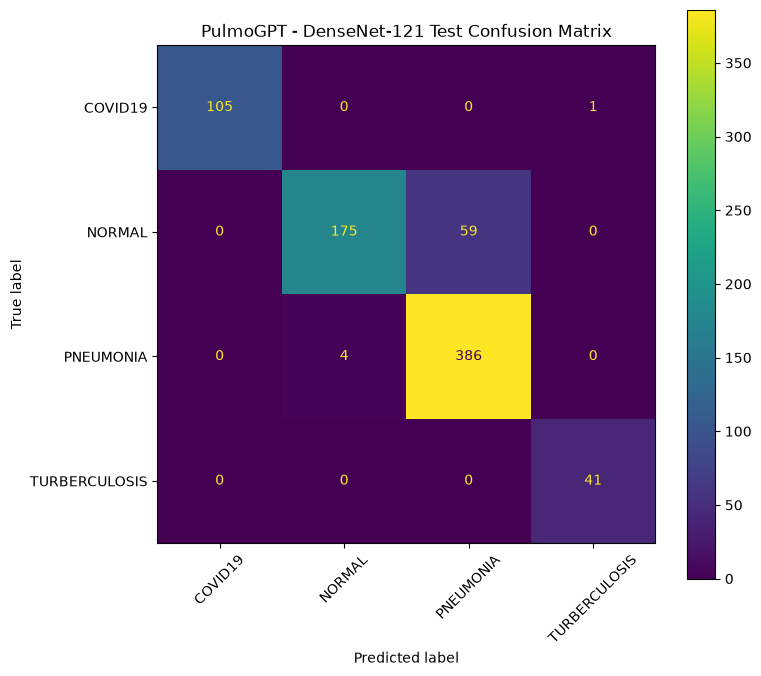

In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# Create confusion matrix
cm = confusion_matrix(
    test_targets,
    test_predictions
)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 7))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes
)

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("PulmoGPT - DenseNet-121 Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [19]:
import torch
import torch.nn.functional as F
import numpy as np


def generate_gradcam(model, image_tensor, target_class):

    model.eval()

    # Target convolutional feature layer
    target_layer = model.features.norm5

    activation = None

    # --------------------------------
    # Forward hook
    # --------------------------------
    def forward_hook(module, input, output):
        nonlocal activation

        # Clone the output to avoid DenseNet's
        # in-place ReLU problem
        activation = output.clone()
        activation.retain_grad()

        # IMPORTANT:
        # Return the clone so subsequent layers
        # operate on the cloned tensor
        return activation

    # Register only a forward hook
    handle = target_layer.register_forward_hook(
        forward_hook
    )

    try:

        # Clear old gradients
        model.zero_grad(set_to_none=True)

        # Add batch dimension
        image = image_tensor.unsqueeze(0).to(device)

        # Forward pass
        output = model(image)

        # Target class score
        score = output[0, target_class]

        # Backpropagation
        score.backward()

        # --------------------------------
        # Get activation gradients
        # --------------------------------

        gradients = activation.grad

        # Global average pooling
        weights = gradients.mean(
            dim=(2, 3),
            keepdim=True
        )

        # Weighted feature maps
        cam = (weights * activation).sum(dim=1)

        # ReLU
        cam = F.relu(cam)

        # Remove batch dimension
        cam = cam.squeeze()

        # Normalize
        cam_min = cam.min()
        cam_max = cam.max()

        if (cam_max - cam_min) > 0:
            cam = (cam - cam_min) / (cam_max - cam_min)

        return (
            cam.detach().cpu().numpy(),
            output.detach().cpu()
        )

    finally:

        # Always remove hook, even if an error occurs
        handle.remove()

In [20]:
model.zero_grad(set_to_none=True)

print("Grad-CAM setup reset.")

Grad-CAM setup reset.


In [16]:
# Fix in-place ReLU operations for Grad-CAM

for module in model.modules():
    if isinstance(module, nn.ReLU):
        module.inplace = False

print("DenseNet ReLU layers updated for Grad-CAM.")

DenseNet ReLU layers updated for Grad-CAM.


In [21]:
sample_index = 0

image_path = test_paths[sample_index]
true_label = test_labels[sample_index]

original_image = Image.open(image_path).convert("RGB")

input_tensor = val_transform(original_image)

model.eval()

with torch.no_grad():
    output = model(
        input_tensor.unsqueeze(0).to(device)
    )

predicted_class = torch.argmax(
    output,
    dim=1
).item()

cam, output = generate_gradcam(
    model,
    input_tensor,
    predicted_class
)

print("Image:", image_path)
print("True class:", classes[true_label])
print("Predicted class:", classes[predicted_class])
print("Grad-CAM shape:", cam.shape)

RuntimeError: Output 0 of BackwardHookFunctionBackward is a view and is being modified inplace. This view was created inside a custom Function (or because an input was returned as-is) and the autograd logic to handle view+inplace would override the custom backward associated with the custom Function, leading to incorrect gradients. This behavior is forbidden. You can fix this by cloning the output of the custom Function.

In [22]:
import torch
import torch.nn as nn
from torchvision import models

# Reload the best trained model from disk
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

weights = models.DenseNet121_Weights.DEFAULT

gradcam_model = models.densenet121(weights=weights)

gradcam_model.classifier = nn.Linear(
    gradcam_model.classifier.in_features,
    4
)

checkpoint = torch.load(
    best_model_path,
    map_location=device
)

gradcam_model.load_state_dict(
    checkpoint["model_state_dict"]
)

gradcam_model = gradcam_model.to(device)
gradcam_model.eval()

print("Fresh DenseNet loaded for Grad-CAM.")
print("Device:", device)

Fresh DenseNet loaded for Grad-CAM.
Device: cuda


In [23]:
for module in gradcam_model.modules():
    
    if isinstance(module, nn.ReLU):
        module.inplace = False

print("ReLU configuration updated.")

ReLU configuration updated.


In [24]:
import torch.nn.functional as F
import numpy as np


def generate_gradcam(model, image_tensor, target_class):

    model.eval()

    # ------------------------------------
    # Forward through DenseNet features
    # ------------------------------------

    x = image_tensor.unsqueeze(0).to(device)

    # We will manually go through feature layers
    # and capture the final convolutional features.
    for name, layer in model.features.named_children():

        x = layer(x)

        # After the final dense block, save the features
        if name == "denseblock4":
            target_features = x.clone()

    # Apply the final normalization
    target_features = model.features.norm5(target_features)

    # Clone before ReLU
    target_features = target_features.clone()

    # Retain gradients
    target_features.retain_grad()

    # Final activation
    activated_features = F.relu(
        target_features,
        inplace=False
    )

    # Global average pooling
    pooled = F.adaptive_avg_pool2d(
        activated_features,
        (1, 1)
    )

    pooled = torch.flatten(
        pooled,
        1
    )

    # Classifier
    output = model.classifier(pooled)

    # ------------------------------------
    # Backpropagate target class
    # ------------------------------------

    model.zero_grad(set_to_none=True)

    score = output[0, target_class]

    score.backward()

    # Get gradients
    gradients = target_features.grad

    # Calculate channel importance
    weights = gradients.mean(
        dim=(2, 3),
        keepdim=True
    )

    # Weighted feature maps
    cam = (weights * target_features).sum(
        dim=1
    )

    # ReLU
    cam = F.relu(
        cam,
        inplace=False
    )

    # Remove batch dimension
    cam = cam.squeeze()

    # Normalize
    cam_min = cam.min()
    cam_max = cam.max()

    if (cam_max - cam_min) > 0:

        cam = (
            cam - cam_min
        ) / (
            cam_max - cam_min
        )

    return (
        cam.detach().cpu().numpy(),
        output.detach().cpu()
    )

In [25]:
sample_index = 0

image_path = test_paths[sample_index]
true_label = test_labels[sample_index]

original_image = Image.open(
    image_path
).convert("RGB")

input_tensor = val_transform(
    original_image
)

# Get prediction
with torch.no_grad():

    prediction_output = gradcam_model(
        input_tensor.unsqueeze(0).to(device)
    )

predicted_class = torch.argmax(
    prediction_output,
    dim=1
).item()

# Generate Grad-CAM
cam, output = generate_gradcam(
    gradcam_model,
    input_tensor,
    predicted_class
)

print("Image:", image_path)
print("True class:", classes[true_label])
print("Predicted class:", classes[predicted_class])
print("Grad-CAM shape:", cam.shape)

Image: D:\PulmoGPT\dataset\test\COVID19\COVID19(460).jpg
True class: COVID19
Predicted class: COVID19
Grad-CAM shape: (7, 7)


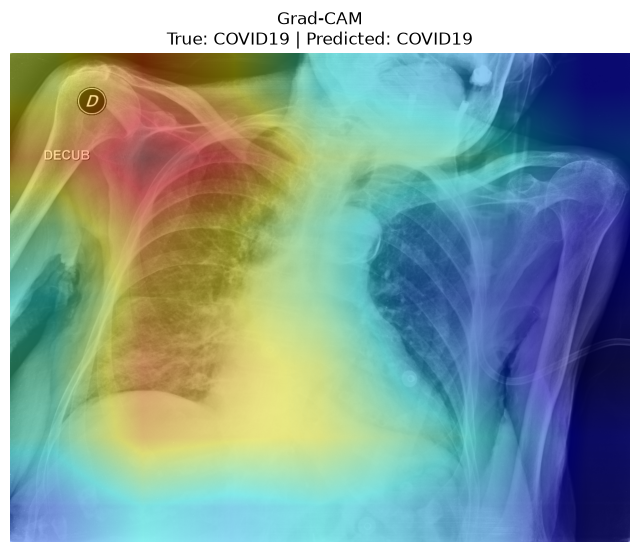

In [26]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------------------
# Resize Grad-CAM to original image size
# -----------------------------------------

original_array = np.array(original_image)

height, width = original_array.shape[:2]

heatmap = cv2.resize(
    cam,
    (width, height)
)

# Convert to 0-255
heatmap_uint8 = np.uint8(
    255 * heatmap
)

# Create heatmap
heatmap_color = cv2.applyColorMap(
    heatmap_uint8,
    cv2.COLORMAP_JET
)

# OpenCV uses BGR, convert to RGB
heatmap_color = cv2.cvtColor(
    heatmap_color,
    cv2.COLOR_BGR2RGB
)

# Convert original image to numpy
original_array = np.array(original_image)

# Create overlay
overlay = cv2.addWeighted(
    original_array,
    0.6,
    heatmap_color,
    0.4,
    0
)

# -----------------------------------------
# Display
# -----------------------------------------

plt.figure(figsize=(8, 8))

plt.imshow(overlay)

plt.title(
    f"Grad-CAM\n"
    f"True: {classes[true_label]} | "
    f"Predicted: {classes[predicted_class]}"
)

plt.axis("off")
plt.show()

In [27]:
import torch
import torch.nn.functional as F
from pathlib import Path
import numpy as np

# Use the trained best model
feature_model = gradcam_model
feature_model.eval()

print("Feature extractor ready.")

Feature extractor ready.


In [28]:
def extract_densenet_features(model, image_tensor):
    
    model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():

        # DenseNet visual feature extraction
        features = model.features(image_tensor)

        # Global average pooling
        features = F.adaptive_avg_pool2d(
            features,
            (1, 1)
        )

        # Convert 1 x 1024 x 1 x 1
        # into 1024-dimensional vector
        features = torch.flatten(
            features,
            start_dim=1
        )

    return features.squeeze(0).cpu().numpy()

In [29]:
sample_index = 0

sample_image = Image.open(
    test_paths[sample_index]
).convert("RGB")

sample_tensor = val_transform(
    sample_image
)

feature_vector = extract_densenet_features(
    feature_model,
    sample_tensor
)

print("Feature vector shape:", feature_vector.shape)
print("Feature vector type:", type(feature_vector))

Feature vector shape: (1024,)
Feature vector type: <class 'numpy.ndarray'>


In [3]:
from transformers import AutoConfig

# BioMedGPT model used as the language-model component
MODEL_NAME = "PharMolix/BioMedGPT-LM-7B"

print("Loading BioMedGPT configuration...")

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

print("BioMedGPT configuration loaded.")

print("\nModel type:", config.model_type)

# Check the hidden dimension
if hasattr(config, "hidden_size"):
    print("Hidden size:", config.hidden_size)

# Some LLaMA-style configurations use this name
if hasattr(config, "hidden_sizes"):
    print("Hidden sizes:", config.hidden_sizes)

print("\nNumber of layers:", getattr(config, "num_hidden_layers", "Not available"))
print("Number of attention heads:", getattr(config, "num_attention_heads", "Not available"))

Loading BioMedGPT configuration...


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

d:\PulmoGPT\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sastra\.cache\huggingface\hub\models--PharMolix--BioMedGPT-LM-7B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


BioMedGPT configuration loaded.

Model type: llama
Hidden size: 4096

Number of layers: 32
Number of attention heads: 32


In [5]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [6]:
import torch.nn as nn

projection = nn.Linear(1024, 4096).to(device)

print("Projection layer created.")
print("Input dimension:", 1024)
print("Output dimension:", 4096)

test_feature = torch.randn(1, 1024).to(device)
projected_feature = projection(test_feature)

print("Input shape:", test_feature.shape)
print("Output shape:", projected_feature.shape)

Projection layer created.
Input dimension: 1024
Output dimension: 4096
Input shape: torch.Size([1, 1024])
Output shape: torch.Size([1, 4096])


In [7]:
from pathlib import Path
import torch

models_path = Path(r"D:\PulmoGPT\models")
models_path.mkdir(exist_ok=True)

projection_path = models_path / "cxr_projection_test.pth"

torch.save(
    projection.state_dict(),
    projection_path
)

print("Projection layer saved.")
print("Saved to:", projection_path)

Projection layer saved.
Saved to: D:\PulmoGPT\models\cxr_projection_test.pth


In [8]:
from transformers import AutoConfig

MODEL_NAME = "PharMolix/BioMedGPT-LM-7B"

print("Loading BioMedGPT configuration...")

config = AutoConfig.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

print("BioMedGPT configuration loaded.")
print("Model type:", config.model_type)
print("Hidden size:", config.hidden_size)
print("Number of layers:", config.num_hidden_layers)
print("Attention heads:", config.num_attention_heads)

Loading BioMedGPT configuration...


BioMedGPT configuration loaded.
Model type: llama
Hidden size: 4096
Number of layers: 32
Attention heads: 32


In [9]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print("VRAM:", round(torch.cuda.get_device_properties(0).total_memory / (1024**3), 2), "GB")

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA RTX 2000 Ada Generation
VRAM: 16.0 GB


In [10]:
try:
    import peft
    print("PEFT installed:", peft.__version__)
except ImportError:
    print("PEFT is NOT installed.")

PEFT is NOT installed.


In [11]:
!python -m pip install -U peft

  Using cached peft-0.20.0-py3-none-any.whl.metadata (14 kB)
  Using cached accelerate-1.14.0-py3-none-any.whl.metadata (19 kB)
Using cached peft-0.20.0-py3-none-any.whl (775 kB)
Using cached accelerate-1.14.0-py3-none-any.whl (389 kB)

   ---------------------------------------- 0/2 [accelerate]
   ---------------------------------------- 0/2 [accelerate]
   ---------------------------------------- 0/2 [accelerate]
   ---------------------------------------- 0/2 [accelerate]
   ---------------------------------------- 0/2 [accelerate]
   ---------------------------------------- 0/2 [accelerate]
   -------------------- ------------------- 1/2 [peft]
   -------------------- ------------------- 1/2 [peft]
   -------------------- ------------------- 1/2 [peft]
   -------------------- ------------------- 1/2 [peft]
   -------------------- ------------------- 1/2 [peft]
   -------------------- ------------------- 1/2 [peft]
   -------------------- ------------------- 1/2 [peft]
   ---------

In [12]:
import peft

print("PEFT installed successfully.")
print("PEFT version:", peft.__version__)

PEFT installed successfully.
PEFT version: 0.20.0


In [13]:
try:
    import bitsandbytes
    print("bitsandbytes installed:", bitsandbytes.__version__)
except ImportError:
    print("bitsandbytes is NOT installed.")

bitsandbytes is NOT installed.


In [14]:
!python -m pip install -U bitsandbytes

   ---------------------------------------- 0.0/39.1 MB ? eta -:--:--
   ---------------------------------------- 0.3/39.1 MB ? eta -:--:--
    --------------------------------------- 0.5/39.1 MB 1.4 MB/s eta 0:00:28
    --------------------------------------- 0.8/39.1 MB 1.5 MB/s eta 0:00:26
   - -------------------------------------- 1.0/39.1 MB 1.5 MB/s eta 0:00:26
   - -------------------------------------- 1.3/39.1 MB 1.5 MB/s eta 0:00:26
   - -------------------------------------- 1.8/39.1 MB 1.6 MB/s eta 0:00:23
   -- ------------------------------------- 2.6/39.1 MB 1.9 MB/s eta 0:00:20
   --- ------------------------------------ 3.4/39.1 MB 2.2 MB/s eta 0:00:17
   ---- ----------------------------------- 4.2/39.1 MB 2.4 MB/s eta 0:00:15
   ---- ----------------------------------- 4.5/39.1 MB 2.4 MB/s eta 0:00:15
   ----- ---------------------------------- 5.2/39.1 MB 2.4 MB/s eta 0:00:15
   ----- ---------------------------------- 5.5/39.1 MB 2.4 MB/s eta 0:00:15
   ------ ---

In [15]:
import bitsandbytes as bnb

print("bitsandbytes installed successfully.")
print("Version:", bnb.__version__)

W0904 09:08:31.079000 29592 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


bitsandbytes installed successfully.
Version: 0.50.2


In [16]:
import bitsandbytes as bnb
import torch

print("bitsandbytes:", bnb.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

bitsandbytes: 0.50.2
CUDA available: True
GPU: NVIDIA RTX 2000 Ada Generation


In [20]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "PharMolix/BioMedGPT-LM-7B"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading BioMedGPT-7B in 4-bit mode...")

biomed_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)

print("BioMedGPT loaded successfully.")

Loading BioMedGPT-7B in 4-bit mode...


ValueError: Using a `device_map`, `tp_plan`, `torch.device` context manager or setting `torch.set_default_device(device)` requires `accelerate`. You can install it with `pip install accelerate`

In [18]:
!python -m pip install -U accelerate

In [19]:
import accelerate

print("Accelerate installed successfully.")
print("Version:", accelerate.__version__)

Accelerate installed successfully.
Version: 1.14.0


In [21]:
import sys
print(sys.executable)

d:\PulmoGPT\.venv\Scripts\python.exe


In [22]:
import sys
!{sys.executable} -m pip install -U accelerate

In [1]:
import sys
import accelerate

print("Python:", sys.executable)
print("Accelerate:", accelerate.__version__)

Python: d:\PulmoGPT\.venv\Scripts\python.exe
Accelerate: 1.14.0


In [2]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

MODEL_NAME = "PharMolix/BioMedGPT-LM-7B"

quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading BioMedGPT-7B in 4-bit mode...")

biomed_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)

print("✅ BioMedGPT loaded successfully!")

Loading BioMedGPT-7B in 4-bit mode...


W0904 09:16:45.535000 11252 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


pytorch_model.bin.index.json:   0%|          | 0.00/26.8k [00:00<?, ?B/s]

d:\PulmoGPT\.venv\Lib\site-packages\huggingface_hub\file_download.py:142: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sastra\.cache\huggingface\hub\models--PharMolix--BioMedGPT-LM-7B. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

...

model.safetensors.index.json:   0%|          | 0.00/28.1k [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/192 [00:00<?, ?B/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


✅ BioMedGPT loaded successfully!


In [3]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

biomed_model = get_peft_model(biomed_model, lora_config)

biomed_model.print_trainable_parameters()

trainable params: 4,194,304 || all params: 6,742,609,920 || trainable%: 0.0622


In [6]:
import torch.nn as nn

DENSENET_DIM = 1024
BIOMEDGPT_DIM = 4096

projection = nn.Sequential(
    nn.Linear(DENSENET_DIM, 2048),
    nn.GELU(),
    nn.Linear(2048, BIOMEDGPT_DIM)
).to(device)

print("Projection created successfully.")
print(projection)

Projection created successfully.
Sequential(
  (0): Linear(in_features=1024, out_features=2048, bias=True)
  (1): GELU(approximate='none')
  (2): Linear(in_features=2048, out_features=4096, bias=True)
)


In [5]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

Device: cuda


In [8]:
# Make sure DenseNet is in evaluation mode
feature_model.eval()

# Extract a real CXR feature
real_feature = extract_densenet_features(
    feature_model,
    image_tensor
)

# Convert NumPy array → PyTorch tensor
real_feature = torch.tensor(
    real_feature,
    dtype=torch.float32
).unsqueeze(0).to(device)

# Pass through projection
projected_feature = projection(real_feature)

print("DenseNet feature shape :", real_feature.shape)
print("Projected feature shape:", projected_feature.shape)

NameError: name 'feature_model' is not defined

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Recreate the same DenseNet-121 architecture
feature_model = models.densenet121(weights=None)

feature_model.classifier = nn.Linear(
    feature_model.classifier.in_features,
    4
)

checkpoint_path = r"D:\PulmoGPT\models\densenet121_best.pth"

# Load checkpoint
checkpoint = torch.load(
    checkpoint_path,
    map_location=device
)

print("Checkpoint keys:", checkpoint.keys())

# Load ONLY the saved model weights
feature_model.load_state_dict(
    checkpoint["model_state_dict"]
)

feature_model = feature_model.to(device)
feature_model.eval()

print("✅ DenseNet-121 restored successfully")
print("Device:", device)
print("Classes:", checkpoint["class_names"])
print("Best validation F1:", checkpoint["best_val_f1"])

Checkpoint keys: dict_keys(['model_state_dict', 'class_names', 'best_val_f1'])
✅ DenseNet-121 restored successfully
Device: cuda
Classes: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Best validation F1: 0.9804178467111909


In [11]:
from pathlib import Path
from PIL import Image
from torchvision import transforms

# Same preprocessing used for validation/test
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Find one real CXR image
image_extensions = {".jpg", ".jpeg", ".png"}

image_path = next(
    p for p in Path(r"D:\PulmoGPT\dataset\train").rglob("*")
    if p.suffix.lower() in image_extensions
)

# Load image
image = Image.open(image_path).convert("RGB")

# Convert to tensor
image_tensor = transform(image)

print("Image:", image_path)
print("Image tensor:", image_tensor.shape)

Image: D:\PulmoGPT\dataset\train\COVID19\COVID19(0).jpg
Image tensor: torch.Size([3, 224, 224])


In [12]:
def extract_densenet_features(model, image_tensor):
    model.eval()

    image_tensor = image_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        features = model.features(image_tensor)
        features = F.adaptive_avg_pool2d(features, (1, 1))
        features = torch.flatten(features, start_dim=1)

    return features.squeeze(0).cpu().numpy()


real_feature = extract_densenet_features(
    feature_model,
    image_tensor
)

real_feature = torch.tensor(
    real_feature,
    dtype=torch.float32
).unsqueeze(0).to(device)

print("DenseNet feature:", real_feature.shape)

DenseNet feature: torch.Size([1, 1024])


In [13]:
projected_feature = projection(real_feature)

print("Projected feature:", projected_feature.shape)

Projected feature: torch.Size([1, 4096])


In [14]:
print("Projected feature shape:", projected_feature.shape)

# BioMedGPT's expected hidden dimension
print("BioMedGPT hidden size:", biomed_model.config.hidden_size)

assert projected_feature.shape[-1] == biomed_model.config.hidden_size

print("✅ DenseNet → Projection → BioMedGPT dimensions match!")

Projected feature shape: torch.Size([1, 4096])
BioMedGPT hidden size: 4096
✅ DenseNet → Projection → BioMedGPT dimensions match!


In [15]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

text = "What abnormality is present in this chest X-ray?"

inputs = tokenizer(
    text,
    return_tensors="pt"
)

input_ids = inputs["input_ids"].to(device)

print("Prompt:", text)
print("Input IDs shape:", input_ids.shape)

print("✅ BioMedGPT tokenizer is ready")

tokenizer_config.json:   0%|          | 0.00/743 [00:00<?, ?B/s]

tokenizer.model: reconstructing file:   0%|          |  0.00B /  500kB            

tokenizer.model: downloading bytes:           |  0.00B            

tokenizer.json:   0%|          | 0.00/1.84M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

Prompt: What abnormality is present in this chest X-ray?
Input IDs shape: torch.Size([1, 15])
✅ BioMedGPT tokenizer is ready


In [16]:
with torch.no_grad():
    output = biomed_model.generate(
        input_ids=input_ids,
        max_new_tokens=50,
        do_sample=False
    )

response = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("BioMedGPT response:")
print(response)

[transformers] Both `max_new_tokens` (=50) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


BioMedGPT response:
What abnormality is present in this chest X-ray? a) Pneumothorax b) Pneumomediastinum c) Pneumopericardium d) Pneumoperitoneum e) Pneumatosis intestinalis
 Unterscheidung zwischen Pneumothorax und


In [17]:
# Get BioMedGPT text embeddings
text_embeddings = biomed_model.get_input_embeddings()(input_ids)

# Add the projected X-ray feature as one visual token
visual_token = projected_feature.unsqueeze(1)

# Combine:
# [VISUAL TOKEN] + [TEXT TOKENS]
multimodal_embeddings = torch.cat(
    [visual_token, text_embeddings],
    dim=1
)

# Attention mask for the new visual token
text_attention_mask = torch.ones_like(input_ids)

visual_attention_mask = torch.ones(
    (input_ids.shape[0], 1),
    dtype=text_attention_mask.dtype,
    device=device
)

multimodal_attention_mask = torch.cat(
    [visual_attention_mask, text_attention_mask],
    dim=1
)

print("Text embeddings:", text_embeddings.shape)
print("Visual token:", visual_token.shape)
print("Multimodal embeddings:", multimodal_embeddings.shape)
print("Attention mask:", multimodal_attention_mask.shape)

print("✅ CXR visual feature successfully connected to BioMedGPT!")

Text embeddings: torch.Size([1, 15, 4096])
Visual token: torch.Size([1, 1, 4096])
Multimodal embeddings: torch.Size([1, 16, 4096])
Attention mask: torch.Size([1, 16])
✅ CXR visual feature successfully connected to BioMedGPT!


In [18]:
with torch.no_grad():
    output = biomed_model.generate(
        inputs_embeds=multimodal_embeddings,
        attention_mask=multimodal_attention_mask,
        max_new_tokens=50,
        do_sample=False
    )

response = tokenizer.decode(
    output[0],
    skip_special_tokens=True
)

print("PulmoGPT multimodal response:")
print(response)

[transformers] Both `max_new_tokens` (=50) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


PulmoGPT multimodal response:

 Unterscheidung der Kranken, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 


In [19]:
# Map your dataset classes to natural medical responses
class_to_response = {
    "COVID19": "The chest X-ray is classified as showing COVID-19.",
    "NORMAL": "The chest X-ray appears normal.",
    "PNEUMONIA": "The chest X-ray is classified as showing pneumonia.",
    "TURBERCULOSIS": "The chest X-ray is classified as showing tuberculosis."
}

question = "What is the diagnosis indicated by this chest X-ray?"

# Get the class from the image path we selected earlier
image_class = image_path.parent.name

answer = class_to_response[image_class]

print("Image class:", image_class)
print("Question:", question)
print("Answer:", answer)

Image class: COVID19
Question: What is the diagnosis indicated by this chest X-ray?
Answer: The chest X-ray is classified as showing COVID-19.


In [20]:
from pathlib import Path

# Training dataset root
train_root = Path(r"D:\PulmoGPT\dataset\train")

# Class → natural-language answer
class_to_response = {
    "COVID19": "The chest X-ray is classified as showing COVID-19.",
    "NORMAL": "The chest X-ray appears normal.",
    "PNEUMONIA": "The chest X-ray is classified as showing pneumonia.",
    "TURBERCULOSIS": "The chest X-ray is classified as showing tuberculosis."
}

question = "What is the diagnosis indicated by this chest X-ray?"

# Collect image paths and labels
training_examples = []

image_extensions = {".jpg", ".jpeg", ".png"}

for class_name in class_to_response:
    class_dir = train_root / class_name

    for image_file in class_dir.rglob("*"):
        if image_file.suffix.lower() in image_extensions:
            training_examples.append({
                "image_path": str(image_file),
                "class_name": class_name,
                "question": question,
                "answer": class_to_response[class_name]
            })

print("Total training examples:", len(training_examples))

# Show a few examples
for example in training_examples[:3]:
    print("\nImage:", example["image_path"])
    print("Class:", example["class_name"])
    print("Question:", example["question"])
    print("Answer:", example["answer"])

Total training examples: 6326

Image: D:\PulmoGPT\dataset\train\COVID19\COVID19(0).jpg
Class: COVID19
Question: What is the diagnosis indicated by this chest X-ray?
Answer: The chest X-ray is classified as showing COVID-19.

Image: D:\PulmoGPT\dataset\train\COVID19\COVID19(1).jpg
Class: COVID19
Question: What is the diagnosis indicated by this chest X-ray?
Answer: The chest X-ray is classified as showing COVID-19.

Image: D:\PulmoGPT\dataset\train\COVID19\COVID19(10).jpg
Class: COVID19
Question: What is the diagnosis indicated by this chest X-ray?
Answer: The chest X-ray is classified as showing COVID-19.


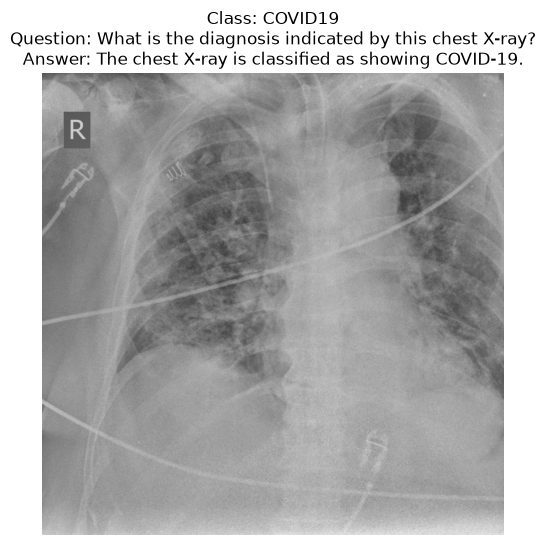

In [21]:
import matplotlib.pyplot as plt
from PIL import Image

# Select one training example
example = training_examples[0]

# Load image
img = Image.open(example["image_path"]).convert("RGB")

# Display image
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.axis("off")
plt.title(
    f"Class: {example['class_name']}\n"
    f"Question: {example['question']}\n"
    f"Answer: {example['answer']}"
)
plt.show()

In [22]:
from collections import Counter

train_counts = Counter(
    example["class_name"]
    for example in training_examples
)

print("Current dataset counts:")
for class_name, count in train_counts.items():
    print(f"{class_name}: {count}")

print("\nTotal:", len(training_examples))

Current dataset counts:
COVID19: 460
NORMAL: 1341
PNEUMONIA: 3875
TURBERCULOSIS: 650

Total: 6326


In [23]:
from sklearn.model_selection import train_test_split

# All image paths and their corresponding classes
image_paths = [example["image_path"] for example in training_examples]
labels = [example["class_name"] for example in training_examples]

# 85% training, 15% validation
train_paths, val_paths, train_labels, val_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.15,
    stratify=labels,
    random_state=42
)

print("Multimodal training images:", len(train_paths))
print("Multimodal validation images:", len(val_paths))

print("\nTraining class distribution:")
for class_name in sorted(set(train_labels)):
    print(class_name, train_labels.count(class_name))

print("\nValidation class distribution:")
for class_name in sorted(set(val_labels)):
    print(class_name, val_labels.count(class_name))

Multimodal training images: 5377
Multimodal validation images: 949

Training class distribution:
COVID19 391
NORMAL 1140
PNEUMONIA 3294
TURBERCULOSIS 552

Validation class distribution:
COVID19 69
NORMAL 201
PNEUMONIA 581
TURBERCULOSIS 98


In [24]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torch

class PulmoMultimodalDataset(Dataset):
    def __init__(self, image_paths, labels, transform):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

        self.class_to_id = {
            "COVID19": 0,
            "NORMAL": 1,
            "PNEUMONIA": 2,
            "TURBERCULOSIS": 3
        }

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image = Image.open(self.image_paths[idx]).convert("RGB")
        image = self.transform(image)

        label = self.class_to_id[self.labels[idx]]

        return {
            "image": image,
            "label": torch.tensor(label, dtype=torch.long),
            "question": "What is the diagnosis indicated by this chest X-ray?"
        }


# Create datasets
multimodal_train_dataset = PulmoMultimodalDataset(
    train_paths,
    train_labels,
    transform
)

multimodal_val_dataset = PulmoMultimodalDataset(
    val_paths,
    val_labels,
    transform
)

# Small batch for testing
multimodal_train_loader = DataLoader(
    multimodal_train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

multimodal_val_loader = DataLoader(
    multimodal_val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Training dataset:", len(multimodal_train_dataset))
print("Validation dataset:", len(multimodal_val_dataset))
print("✅ Multimodal DataLoaders created")

Training dataset: 5377
Validation dataset: 949
✅ Multimodal DataLoaders created


In [25]:
batch = next(iter(multimodal_train_loader))

print("Image batch shape:", batch["image"].shape)
print("Label batch shape:", batch["label"].shape)
print("Labels:", batch["label"].tolist())
print("Questions:", batch["question"])

print("✅ Batch loading works!")

Image batch shape: torch.Size([4, 3, 224, 224])
Label batch shape: torch.Size([4])
Labels: [1, 0, 2, 3]
Questions: ['What is the diagnosis indicated by this chest X-ray?', 'What is the diagnosis indicated by this chest X-ray?', 'What is the diagnosis indicated by this chest X-ray?', 'What is the diagnosis indicated by this chest X-ray?']
✅ Batch loading works!


In [26]:
images = batch["image"].to(device)

feature_model.eval()

with torch.no_grad():
    densenet_features = feature_model.features(images)
    densenet_features = F.adaptive_avg_pool2d(
        densenet_features, (1, 1)
    )
    densenet_features = torch.flatten(
        densenet_features, start_dim=1
    )

print("Images:", images.shape)
print("DenseNet features:", densenet_features.shape)

# Pass through projection
projected_features = projection(densenet_features)

print("Projected features:", projected_features.shape)

print("✅ Batch successfully passed through DenseNet → Projection")

Images: torch.Size([4, 3, 224, 224])
DenseNet features: torch.Size([4, 1024])
Projected features: torch.Size([4, 4096])
✅ Batch successfully passed through DenseNet → Projection


In [27]:
# Freeze DenseNet completely
for param in feature_model.parameters():
    param.requires_grad = False

# Make sure Projection is trainable
for param in projection.parameters():
    param.requires_grad = True

# Check LoRA / BioMedGPT trainable parameters
print("BioMedGPT + LoRA trainable parameters:")
biomed_model.print_trainable_parameters()

# Count Projection parameters
projection_params = sum(
    p.numel()
    for p in projection.parameters()
    if p.requires_grad
)

print("\nProjection trainable parameters:", projection_params)

# Check DenseNet
densenet_trainable = sum(
    p.numel()
    for p in feature_model.parameters()
    if p.requires_grad
)

print("DenseNet trainable parameters:", densenet_trainable)

# GPU memory
if torch.cuda.is_available():
    print(
        f"\nGPU memory allocated: "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )
    print(
        f"GPU memory reserved: "
        f"{torch.cuda.memory_reserved()/1024**3:.2f} GB"
    )

print("\n✅ Training configuration ready")

BioMedGPT + LoRA trainable parameters:
trainable params: 4,194,304 || all params: 6,742,609,920 || trainable%: 0.0622

Projection trainable parameters: 10491904
DenseNet trainable parameters: 0

GPU memory allocated: 4.24 GB
GPU memory reserved: 4.63 GB

✅ Training configuration ready


In [28]:
# Get one training example
example = training_examples[0]

# Prepare image
img = Image.open(example["image_path"]).convert("RGB")
img_tensor = transform(img).unsqueeze(0).to(device)

# Extract DenseNet feature
with torch.no_grad():
    visual_features = feature_model.features(img_tensor)
    visual_features = F.adaptive_avg_pool2d(
        visual_features, (1, 1)
    )
    visual_features = torch.flatten(
        visual_features, start_dim=1
    )

# Project visual feature
visual_token = projection(visual_features).unsqueeze(1)

# Build question + answer
prompt = (
    "What is the diagnosis indicated by this chest X-ray?\n"
    "Answer: "
)

target_text = example["answer"]

prompt_ids = tokenizer(
    prompt,
    return_tensors="pt",
    add_special_tokens=True
)["input_ids"].to(device)

target_ids = tokenizer(
    target_text,
    return_tensors="pt",
    add_special_tokens=False
)["input_ids"].to(device)

# Text embeddings
prompt_embeddings = biomed_model.get_input_embeddings()(prompt_ids)
target_embeddings = biomed_model.get_input_embeddings()(target_ids)

# Combine visual + prompt + answer
inputs_embeds = torch.cat(
    [visual_token, prompt_embeddings, target_embeddings],
    dim=1
)

# Labels:
# -100 means "don't calculate loss here"
visual_labels = torch.full(
    (1, 1),
    -100,
    dtype=torch.long,
    device=device
)

prompt_labels = torch.full(
    prompt_ids.shape,
    -100,
    dtype=torch.long,
    device=device
)

labels = torch.cat(
    [visual_labels, prompt_labels, target_ids],
    dim=1
)

# Attention mask
attention_mask = torch.ones(
    inputs_embeds.shape[:2],
    dtype=torch.long,
    device=device
)

# Forward pass
outputs = biomed_model(
    inputs_embeds=inputs_embeds,
    attention_mask=attention_mask,
    labels=labels
)

print("Input embeddings:", inputs_embeds.shape)
print("Labels:", labels.shape)
print("Loss:", outputs.loss.item())

print("✅ Multimodal training loss calculated successfully!")

Input embeddings: torch.Size([1, 36, 4096])
Labels: torch.Size([1, 36])
Loss: 2.0145297050476074
✅ Multimodal training loss calculated successfully!


In [29]:
# Clear any old gradients
projection.zero_grad(set_to_none=True)
biomed_model.zero_grad(set_to_none=True)

# Backpropagate the multimodal loss
outputs.loss.backward()

# Check Projection gradients
projection_grad = 0.0

for param in projection.parameters():
    if param.grad is not None:
        projection_grad += param.grad.abs().mean().item()

# Check LoRA gradients
lora_grad = 0.0
lora_layers = 0

for name, param in biomed_model.named_parameters():
    if param.requires_grad and param.grad is not None:
        lora_grad += param.grad.abs().mean().item()
        lora_layers += 1

print("Projection gradient:", projection_grad)
print("LoRA gradient:", lora_grad)
print("Trainable BioMedGPT layers with gradients:", lora_layers)

if projection_grad > 0:
    print("✅ Projection is receiving gradients")
else:
    print("❌ Projection is NOT receiving gradients")

if lora_grad > 0:
    print("✅ LoRA is receiving gradients")
else:
    print("❌ LoRA is NOT receiving gradients")

Projection gradient: 0.05796200782060623
LoRA gradient: 0.059610253090795595
Trainable BioMedGPT layers with gradients: 128
✅ Projection is receiving gradients
✅ LoRA is receiving gradients


In [30]:
import json
from pathlib import Path

config_path = Path(r"D:\PulmoGPT\models\pulmogpt_training_config.json")

training_config = {
    "vision_encoder": "DenseNet-121",
    "vision_feature_dim": 1024,
    "projection_dim": 4096,
    "language_model": "PharMolix/BioMedGPT-LM-7B",
    "quantization": "4-bit NF4",
    "lora_r": 8,
    "lora_alpha": 16,
    "lora_dropout": 0.05,
    "lora_target_modules": ["q_proj", "v_proj"],
    "trainable_components": ["projection", "LoRA"],
    "frozen_components": ["DenseNet-121", "BioMedGPT base weights"],
    "train_images": len(train_paths),
    "validation_images": len(val_paths),
    "test_images": 771,
    "random_seed": 42
}

with open(config_path, "w") as f:
    json.dump(training_config, f, indent=4)

print("✅ Training configuration saved")
print(config_path)

✅ Training configuration saved
D:\PulmoGPT\models\pulmogpt_training_config.json


In [33]:
import torch

# Collect trainable parameters
projection_parameters = [
    p for p in projection.parameters()
    if p.requires_grad
]

lora_parameters = [
    p for p in biomed_model.parameters()
    if p.requires_grad
]

optimizer = torch.optim.AdamW(
    [
        {
            "params": projection_parameters,
            "lr": 1e-4
        },
        {
            "params": lora_parameters,
            "lr": 2e-5
        }
    ],
    weight_decay=0.01
)

print("Optimizer created successfully")
print("Projection parameters:", sum(p.numel() for p in projection_parameters))
print("LoRA parameters:", sum(p.numel() for p in lora_parameters))

for i, group in enumerate(optimizer.param_groups):
    print(f"Parameter group {i+1} learning rate:", group["lr"])

print("✅ Optimizer ready")

Optimizer created successfully
Projection parameters: 10491904
LoRA parameters: 4194304
Parameter group 1 learning rate: 0.0001
Parameter group 2 learning rate: 2e-05
✅ Optimizer ready


In [34]:
# Training configuration

NUM_EPOCHS = 2

# Keep this small because BioMedGPT-7B is being trained with LoRA
BATCH_SIZE = 1

# Accumulate gradients to get an effective batch size of 4
GRADIENT_ACCUMULATION_STEPS = 4

# Maximum number of generated/target tokens used for training
MAX_TARGET_LENGTH = 64

# Gradient clipping for stability
MAX_GRAD_NORM = 1.0

print("Training configuration")
print("----------------------")
print("Epochs:", NUM_EPOCHS)
print("Batch size:", BATCH_SIZE)
print("Gradient accumulation:", GRADIENT_ACCUMULATION_STEPS)
print("Effective batch size:",
      BATCH_SIZE * GRADIENT_ACCUMULATION_STEPS)
print("Maximum target length:", MAX_TARGET_LENGTH)
print("Maximum gradient norm:", MAX_GRAD_NORM)

print("\nTrainable components:")
print("  Projection: YES")
print("  LoRA: YES")
print("  DenseNet: NO")
print("  BioMedGPT base: NO")

print("\n✅ Training configuration ready")

Training configuration
----------------------
Epochs: 2
Batch size: 1
Gradient accumulation: 4
Effective batch size: 4
Maximum target length: 64
Maximum gradient norm: 1.0

Trainable components:
  Projection: YES
  LoRA: YES
  DenseNet: NO
  BioMedGPT base: NO

✅ Training configuration ready


In [36]:
from tqdm.auto import tqdm
import numpy as np
import torch

feature_dir = Path(r"D:\PulmoGPT\models\precomputed_features")
feature_dir.mkdir(parents=True, exist_ok=True)

feature_model.eval()

print("Precomputing DenseNet features...")
print("Total images:", len(train_paths))

for image_path in tqdm(train_paths):
    image_name = Path(image_path).stem
    feature_path = feature_dir / f"{image_name}.npy"

    # Skip if already computed
    if feature_path.exists():
        continue

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = feature_model.features(image_tensor)
        features = F.adaptive_avg_pool2d(features, (1, 1))
        features = torch.flatten(features, start_dim=1)

    np.save(
        feature_path,
        features.squeeze(0).cpu().numpy()
    )

print("\n✅ DenseNet feature precomputation complete!")
print("Features saved to:", feature_dir)

Precomputing DenseNet features...
Total images: 5377


  0%|          | 0/5377 [00:00<?, ?it/s]


✅ DenseNet feature precomputation complete!
Features saved to: D:\PulmoGPT\models\precomputed_features


In [37]:
from torch.utils.data import Dataset, DataLoader
import numpy as np
import torch

class PulmoFeatureDataset(Dataset):
    def __init__(self, image_paths, labels, feature_dir):
        self.image_paths = image_paths
        self.labels = labels
        self.feature_dir = Path(feature_dir)

        self.class_to_id = {
            "COVID19": 0,
            "NORMAL": 1,
            "PNEUMONIA": 2,
            "TURBERCULOSIS": 3
        }

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = Path(self.image_paths[idx])

        # Load precomputed 1024-D DenseNet feature
        feature_path = self.feature_dir / f"{image_path.stem}.npy"
        feature = np.load(feature_path)

        return {
            "feature": torch.tensor(feature, dtype=torch.float32),
            "label": torch.tensor(
                self.class_to_id[self.labels[idx]],
                dtype=torch.long
            ),
            "question": "What is the diagnosis indicated by this chest X-ray?",
            "answer": {
                "COVID19":
                    "The chest X-ray is classified as showing COVID-19.",
                "NORMAL":
                    "The chest X-ray appears normal.",
                "PNEUMONIA":
                    "The chest X-ray is classified as showing pneumonia.",
                "TURBERCULOSIS":
                    "The chest X-ray is classified as showing tuberculosis."
            }[self.labels[idx]]
        }


# Create feature datasets
feature_train_dataset = PulmoFeatureDataset(
    train_paths,
    train_labels,
    feature_dir
)

feature_val_dataset = PulmoFeatureDataset(
    val_paths,
    val_labels,
    feature_dir
)

# DataLoaders
feature_train_loader = DataLoader(
    feature_train_dataset,
    batch_size=1,
    shuffle=True,
    num_workers=0
)

feature_val_loader = DataLoader(
    feature_val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print("Training feature dataset:", len(feature_train_dataset))
print("Validation feature dataset:", len(feature_val_dataset))
print("✅ Feature DataLoaders created")

Training feature dataset: 5377
Validation feature dataset: 949
✅ Feature DataLoaders created


In [38]:
feature_batch = next(iter(feature_train_loader))

features = feature_batch["feature"].to(device)

print("Feature batch:", features.shape)
print("Labels:", feature_batch["label"].tolist())
print("Question:", feature_batch["question"][0])
print("Answer:", feature_batch["answer"][0])

# Pass through Projection
with torch.no_grad():
    test_projected = projection(features)

print("Projected batch:", test_projected.shape)

print("✅ Precomputed feature → Projection pipeline works!")

Feature batch: torch.Size([1, 1024])
Labels: [2]
Question: What is the diagnosis indicated by this chest X-ray?
Answer: The chest X-ray is classified as showing pneumonia.
Projected batch: torch.Size([1, 4096])
✅ Precomputed feature → Projection pipeline works!


In [39]:
# Get one batch
train_batch = next(iter(feature_train_loader))

features = train_batch["feature"].to(device)
answer_text = train_batch["answer"][0]

# Project the DenseNet feature
visual_token = projection(features).unsqueeze(1)

# Prepare prompt
prompt = (
    "What is the diagnosis indicated by this chest X-ray?\n"
    "Answer: "
)

prompt_ids = tokenizer(
    prompt,
    return_tensors="pt",
    add_special_tokens=True
)["input_ids"].to(device)

# Prepare target answer
target_ids = tokenizer(
    answer_text,
    return_tensors="pt",
    add_special_tokens=False,
    truncation=True,
    max_length=MAX_TARGET_LENGTH
)["input_ids"].to(device)

# Convert text tokens to embeddings
prompt_embeddings = biomed_model.get_input_embeddings()(prompt_ids)
target_embeddings = biomed_model.get_input_embeddings()(target_ids)

# Combine visual + prompt + answer
inputs_embeds = torch.cat(
    [visual_token, prompt_embeddings, target_embeddings],
    dim=1
)

# Ignore visual token and prompt when calculating loss
visual_labels = torch.full(
    (1, 1),
    -100,
    dtype=torch.long,
    device=device
)

prompt_labels = torch.full(
    prompt_ids.shape,
    -100,
    dtype=torch.long,
    device=device
)

labels = torch.cat(
    [visual_labels, prompt_labels, target_ids],
    dim=1
)

attention_mask = torch.ones(
    inputs_embeds.shape[:2],
    dtype=torch.long,
    device=device
)

# Clear previous gradients
optimizer.zero_grad(set_to_none=True)

# Forward pass
outputs = biomed_model(
    inputs_embeds=inputs_embeds,
    attention_mask=attention_mask,
    labels=labels
)

loss = outputs.loss

# Backpropagation
loss.backward()

# Prevent exploding gradients
torch.nn.utils.clip_grad_norm_(
    list(projection.parameters()) +
    [p for p in biomed_model.parameters() if p.requires_grad],
    MAX_GRAD_NORM
)

# Update Projection + LoRA
optimizer.step()

print("Training example:", answer_text)
print("Loss before update:", loss.item())
print("✅ One real Projection + LoRA training step completed!")

if torch.cuda.is_available():
    print(
        f"GPU memory allocated: "
        f"{torch.cuda.memory_allocated()/1024**3:.2f} GB"
    )

Training example: The chest X-ray is classified as showing pneumonia.
Loss before update: 1.770988941192627
✅ One real Projection + LoRA training step completed!
GPU memory allocated: 4.42 GB


In [40]:
from tqdm.auto import tqdm
import numpy as np

print("Precomputing validation DenseNet features...")
print("Total validation images:", len(val_paths))

feature_model.eval()

for image_path in tqdm(val_paths):
    image_name = Path(image_path).stem
    feature_path = feature_dir / f"{image_name}.npy"

    if feature_path.exists():
        continue

    image = Image.open(image_path).convert("RGB")
    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        features = feature_model.features(image_tensor)
        features = F.adaptive_avg_pool2d(features, (1, 1))
        features = torch.flatten(features, start_dim=1)

    np.save(
        feature_path,
        features.squeeze(0).cpu().numpy()
    )

print("\n✅ Validation feature precomputation complete!")

Precomputing validation DenseNet features...
Total validation images: 949


  0%|          | 0/949 [00:00<?, ?it/s]


✅ Validation feature precomputation complete!


In [41]:
# Reset optimizer for the actual training run

optimizer = torch.optim.AdamW(
    [
        {
            "params": [
                p for p in projection.parameters()
                if p.requires_grad
            ],
            "lr": 1e-4
        },
        {
            "params": [
                p for p in biomed_model.parameters()
                if p.requires_grad
            ],
            "lr": 2e-5
        }
    ],
    weight_decay=0.01
)

# Clear any leftover gradients
projection.zero_grad(set_to_none=True)
biomed_model.zero_grad(set_to_none=True)

print("✅ Optimizer reset successfully")
print("Projection LR: 1e-4")
print("LoRA LR: 2e-5")
print("Gradients cleared")

✅ Optimizer reset successfully
Projection LR: 1e-4
LoRA LR: 2e-5
Gradients cleared


In [42]:
import os
import time
from tqdm.auto import tqdm

checkpoint_dir = Path(r"D:\PulmoGPT\models\multimodal_checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

best_val_loss = float("inf")

class_to_answer = {
    "COVID19":
        "The chest X-ray is classified as showing COVID-19.",
    "NORMAL":
        "The chest X-ray appears normal.",
    "PNEUMONIA":
        "The chest X-ray is classified as showing pneumonia.",
    "TURBERCULOSIS":
        "The chest X-ray is classified as showing tuberculosis."
}

def calculate_multimodal_loss(feature, answer_text):
    """
    Build:
    [visual token] + [question tokens] + [answer tokens]
    and calculate loss only on the answer.
    """

    # Projection
    visual_token = projection(feature).unsqueeze(1)

    # Question
    prompt = (
        "What is the diagnosis indicated by this chest X-ray?\n"
        "Answer: "
    )

    prompt_ids = tokenizer(
        prompt,
        return_tensors="pt",
        add_special_tokens=True
    )["input_ids"].to(device)

    # Answer
    target_ids = tokenizer(
        answer_text,
        return_tensors="pt",
        add_special_tokens=False,
        truncation=True,
        max_length=MAX_TARGET_LENGTH
    )["input_ids"].to(device)

    # Embeddings
    prompt_embeddings = (
        biomed_model.get_input_embeddings()(prompt_ids)
    )

    target_embeddings = (
        biomed_model.get_input_embeddings()(target_ids)
    )

    # Multimodal sequence
    inputs_embeds = torch.cat(
        [
            visual_token,
            prompt_embeddings,
            target_embeddings
        ],
        dim=1
    )

    # Ignore visual + prompt tokens in loss
    visual_labels = torch.full(
        (1, 1),
        -100,
        dtype=torch.long,
        device=device
    )

    prompt_labels = torch.full(
        prompt_ids.shape,
        -100,
        dtype=torch.long,
        device=device
    )

    labels = torch.cat(
        [
            visual_labels,
            prompt_labels,
            target_ids
        ],
        dim=1
    )

    attention_mask = torch.ones(
        inputs_embeds.shape[:2],
        dtype=torch.long,
        device=device
    )

    outputs = biomed_model(
        inputs_embeds=inputs_embeds,
        attention_mask=attention_mask,
        labels=labels
    )

    return outputs.loss


# ============================
# TRAINING
# ============================

training_history = []

for epoch in range(NUM_EPOCHS):

    print("\n" + "=" * 60)
    print(f"EPOCH {epoch + 1}/{NUM_EPOCHS}")
    print("=" * 60)

    projection.train()
    biomed_model.train()

    optimizer.zero_grad(set_to_none=True)

    running_loss = 0.0
    optimizer_steps = 0

    start_time = time.time()

    progress = tqdm(
        enumerate(feature_train_loader),
        total=len(feature_train_loader),
        desc=f"Training Epoch {epoch + 1}"
    )

    for step, batch_data in progress:

        feature = batch_data["feature"].to(
            device,
            non_blocking=True
        )

        answer_text = batch_data["answer"][0]

        loss = calculate_multimodal_loss(
            feature,
            answer_text
        )

        # Gradient accumulation
        loss_for_backward = (
            loss / GRADIENT_ACCUMULATION_STEPS
        )

        loss_for_backward.backward()

        running_loss += loss.item()

        # Optimizer update
        if (
            (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0
            or (step + 1) == len(feature_train_loader)
        ):

            torch.nn.utils.clip_grad_norm_(
                list(projection.parameters()) +
                [
                    p for p in biomed_model.parameters()
                    if p.requires_grad
                ],
                MAX_GRAD_NORM
            )

            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            optimizer_steps += 1

        # Update progress bar
        avg_loss = running_loss / (step + 1)

        progress.set_postfix(
            loss=f"{avg_loss:.4f}"
        )

    train_loss = running_loss / len(feature_train_loader)

    # ============================
    # VALIDATION
    # ============================

    projection.eval()
    biomed_model.eval()

    val_loss_total = 0.0

    with torch.no_grad():

        val_progress = tqdm(
            feature_val_loader,
            total=len(feature_val_loader),
            desc=f"Validation Epoch {epoch + 1}"
        )

        for batch_data in val_progress:

            feature = batch_data["feature"].to(device)
            answer_text = batch_data["answer"][0]

            loss = calculate_multimodal_loss(
                feature,
                answer_text
            )

            val_loss_total += loss.item()

            val_progress.set_postfix(
                loss=f"{loss.item():.4f}"
            )

    val_loss = val_loss_total / len(feature_val_loader)

    elapsed = time.time() - start_time

    print("\nEpoch results:")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")
    print(f"Time:       {elapsed / 60:.2f} minutes")

    training_history.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "val_loss": val_loss
    })

    # ============================
    # SAVE BEST CHECKPOINT
    # ============================

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            {
                "projection_state_dict":
                    projection.state_dict(),
                "lora_state_dict":
                    {
                        k: v.cpu()
                        for k, v in biomed_model.state_dict().items()
                        if "lora_" in k
                    },
                "optimizer_state_dict":
                    optimizer.state_dict(),
                "epoch":
                    epoch + 1,
                "train_loss":
                    train_loss,
                "val_loss":
                    val_loss
            },
            checkpoint_dir / "pulmogpt_best.pth"
        )

        print("💾 Best multimodal checkpoint saved!")

print("\n" + "=" * 60)
print("🎉 MULTIMODAL TRAINING COMPLETE")
print("=" * 60)

print("Best validation loss:", best_val_loss)
print("Checkpoint:", checkpoint_dir / "pulmogpt_best.pth")


EPOCH 1/2


Training Epoch 1:   0%|          | 0/5377 [00:00<?, ?it/s]

Validation Epoch 1:   0%|          | 0/949 [00:00<?, ?it/s]


Epoch results:
Train Loss: 0.0354
Val Loss:   0.0061
Time:       53.42 minutes
💾 Best multimodal checkpoint saved!

EPOCH 2/2


Training Epoch 2:   0%|          | 0/5377 [00:00<?, ?it/s]

Validation Epoch 2:   0%|          | 0/949 [00:00<?, ?it/s]


Epoch results:
Train Loss: 0.0027
Val Loss:   0.0048
Time:       52.30 minutes
💾 Best multimodal checkpoint saved!

🎉 MULTIMODAL TRAINING COMPLETE
Best validation loss: 0.004838523831337795
Checkpoint: D:\PulmoGPT\models\multimodal_checkpoints\pulmogpt_best.pth


In [43]:
import os
import torch

checkpoint_path = r"D:\PulmoGPT\models\multimodal_checkpoints\pulmogpt_best.pth"

print("Checkpoint exists:", os.path.exists(checkpoint_path))
print("Checkpoint path:", checkpoint_path)

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False
)

print("Checkpoint loaded successfully.")
print("Checkpoint type:", type(checkpoint))

if isinstance(checkpoint, dict):
    print("\nCheckpoint keys:")
    for key in checkpoint.keys():
        print(" -", key)

Checkpoint exists: True
Checkpoint path: D:\PulmoGPT\models\multimodal_checkpoints\pulmogpt_best.pth
Checkpoint loaded successfully.
Checkpoint type: <class 'dict'>

Checkpoint keys:
 - projection_state_dict
 - lora_state_dict
 - optimizer_state_dict
 - epoch
 - train_loss
 - val_loss


In [44]:
lora_keys = list(checkpoint["lora_state_dict"].keys())

print("Number of LoRA parameters:", len(lora_keys))
print("\nFirst 20 LoRA keys:")

for key in lora_keys[:20]:
    print(key)

Number of LoRA parameters: 128

First 20 LoRA keys:
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight
base_model.model.model.layers.1.self_attn.v_proj.lora_B.default.weight
base_model.model.model.layers.2.self_attn.q_proj.lora_A.default.weight
base_model.model.model.layers.2.self_attn.q_proj.lora_B.default.weight
base_model.model.model.layers.2.self_attn.v_proj.lora_A.default.weight
base_model.model.model.layers.2.self_attn.v_proj.lora_B.default.weight
base_model.model.model.layers.3.self_attn.q_proj.lora_A.default.weight
base_model.model.model.la

In [45]:
projection_keys = list(checkpoint["projection_state_dict"].keys())

print("\nProjection parameters:")
for key in projection_keys:
    print(key)


Projection parameters:
0.weight
0.bias
2.weight
2.bias


In [46]:
print("=== Projection shapes ===")

for key, value in checkpoint["projection_state_dict"].items():
    print(f"{key}: {tuple(value.shape)}")

print("\n=== Training information ===")
print("Epoch:", checkpoint["epoch"])
print("Train loss:", checkpoint["train_loss"])
print("Validation loss:", checkpoint["val_loss"])

=== Projection shapes ===
0.weight: (2048, 1024)
0.bias: (2048,)
2.weight: (4096, 2048)
2.bias: (4096,)

=== Training information ===
Epoch: 2
Train loss: 0.002670870471737558
Validation loss: 0.004838523831337795


In [47]:
print("=== LoRA parameter shapes ===")

for key, value in list(checkpoint["lora_state_dict"].items())[:8]:
    print(key, tuple(value.shape))

=== LoRA parameter shapes ===
base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight (8, 4096)
base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight (4096, 8)
base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight (8, 4096)
base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight (4096, 8)
base_model.model.model.layers.1.self_attn.q_proj.lora_A.default.weight (8, 4096)
base_model.model.model.layers.1.self_attn.q_proj.lora_B.default.weight (4096, 8)
base_model.model.model.layers.1.self_attn.v_proj.lora_A.default.weight (8, 4096)
base_model.model.model.layers.1.self_attn.v_proj.lora_B.default.weight (4096, 8)


In [48]:
import torch
import torch.nn as nn

from transformers import (
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model

MODEL_NAME = "PharMolix/BioMedGPT-LM-7B"

# 4-bit configuration
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

print("Loading BioMedGPT-7B...")

biomed_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)

print("✅ BioMedGPT loaded!")

Loading BioMedGPT-7B...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

✅ BioMedGPT loaded!


In [49]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

biomed_lora = get_peft_model(
    biomed_model,
    lora_config
)

print("✅ LoRA attached!")

biomed_lora.print_trainable_parameters()

✅ LoRA attached!
trainable params: 4,194,304 || all params: 6,742,609,920 || trainable%: 0.0622


In [50]:
import torch
import torch.nn as nn

# -----------------------------------------
# 1. Recreate the trained projection
# -----------------------------------------

projection = nn.Sequential(
    nn.Linear(1024, 2048),
    nn.ReLU(),
    nn.Linear(2048, 4096)
).to(device)

projection.load_state_dict(
    checkpoint["projection_state_dict"]
)

projection.eval()

print("✅ Trained projection loaded!")


# -----------------------------------------
# 2. Load the trained LoRA weights
# -----------------------------------------

load_result = biomed_lora.load_state_dict(
    checkpoint["lora_state_dict"],
    strict=True
)

print("✅ Trained LoRA weights loaded!")
print(load_result)


# -----------------------------------------
# 3. Put models in evaluation mode
# -----------------------------------------

biomed_lora.eval()

print("\n🎉 TRAINED PULMOGPT COMPONENTS LOADED!")

✅ Trained projection loaded!


RuntimeError: Error(s) in loading state_dict for PeftModelForCausalLM:
	Missing key(s) in state_dict: "base_model.model.model.embed_tokens.weight", "base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight", "base_model.model.model.layers.0.self_attn.k_proj.weight", "base_model.model.model.layers.0.self_attn.v_proj.base_layer.weight", "base_model.model.model.layers.0.self_attn.o_proj.weight", "base_model.model.model.layers.0.mlp.gate_proj.weight", "base_model.model.model.layers.0.mlp.up_proj.weight", "base_model.model.model.layers.0.mlp.down_proj.weight", "base_model.model.model.layers.0.input_layernorm.weight", "base_model.model.model.layers.0.post_attention_layernorm.weight", "base_model.model.model.layers.1.self_attn.q_proj.base_layer.weight", "base_model.model.model.layers.1.self_attn.k_proj.weight", "base_model.model.model.layers.1.self_attn.v_proj.base_layer.weight", "base_model.model.model.layers.1.self_attn.o_proj.weight", "base_model.model.model.layers.1.mlp.gate_pro

In [51]:
from peft import set_peft_model_state_dict

print("Loading trained LoRA weights...")

result = set_peft_model_state_dict(
    biomed_lora,
    checkpoint["lora_state_dict"]
)

print("✅ Trained LoRA weights loaded!")
print(result)

Loading trained LoRA weights...
✅ Trained LoRA weights loaded!
_IncompatibleKeys(missing_keys=['base_model.model.model.embed_tokens.weight', 'base_model.model.model.layers.0.self_attn.q_proj.base_layer.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.q_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.k_proj.weight', 'base_model.model.model.layers.0.self_attn.v_proj.base_layer.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_A.default.weight', 'base_model.model.model.layers.0.self_attn.v_proj.lora_B.default.weight', 'base_model.model.model.layers.0.self_attn.o_proj.weight', 'base_model.model.model.layers.0.mlp.gate_proj.weight', 'base_model.model.model.layers.0.mlp.up_proj.weight', 'base_model.model.model.layers.0.mlp.down_proj.weight', 'base_model.model.model.layers.0.input_layernorm.weight', 'base_model.model.model.layers.0.post_attention_layernorm.weight', 'base_model.mo

In [52]:
print("Projection:", projection[0].weight.shape, "→", projection[2].weight.shape)
print("LoRA parameters:", len(checkpoint["lora_state_dict"]))

print("\n✅ PulmoGPT trained components are ready!")

Projection: torch.Size([2048, 1024]) → torch.Size([4096, 2048])
LoRA parameters: 128

✅ PulmoGPT trained components are ready!


In [53]:
import torch
import torch.nn as nn
from torchvision import models

DENSENET_PATH = r"D:\PulmoGPT\models\densenet121_best.pth"

print("Loading trained DenseNet-121...")

# Recreate DenseNet-121
densenet = models.densenet121(weights=None)

# Your classifier has 4 CXR classes
densenet.classifier = nn.Linear(
    densenet.classifier.in_features,
    4
)

# Load checkpoint
densenet_checkpoint = torch.load(
    DENSENET_PATH,
    map_location="cpu",
    weights_only=False
)

# Handle the checkpoint format
if isinstance(densenet_checkpoint, dict) and "model_state_dict" in densenet_checkpoint:
    densenet.load_state_dict(densenet_checkpoint["model_state_dict"])
else:
    densenet.load_state_dict(densenet_checkpoint)

densenet = densenet.to(device)
densenet.eval()

print("✅ Trained DenseNet-121 loaded!")
print("Feature dimension: 1024")
print("Classes: 4")

Loading trained DenseNet-121...
✅ Trained DenseNet-121 loaded!
Feature dimension: 1024
Classes: 4


In [54]:
# Take one image from the test dataset
sample_image, sample_label = test_dataset[0]

with torch.no_grad():
    x = sample_image.unsqueeze(0).to(device)

    features = densenet.features(x)
    features = torch.nn.functional.adaptive_avg_pool2d(
        features, (1, 1)
    )
    features = torch.flatten(features, 1)

    logits = densenet.classifier(features)

print("Image shape:", tuple(sample_image.shape))
print("DenseNet feature shape:", tuple(features.shape))
print("Classifier output shape:", tuple(logits.shape))
print("Predicted class:", logits.argmax(dim=1).item())
print("Actual class:", sample_label)

NameError: name 'test_dataset' is not defined

In [55]:
from pathlib import Path
from PIL import Image
import torch
from torchvision import transforms

# Test dataset location
TEST_DIR = Path(r"D:\PulmoGPT\dataset\test")

# Find the first valid image
valid_extensions = {".jpg", ".jpeg", ".png", ".bmp"}

image_paths = [
    p for p in TEST_DIR.rglob("*")
    if p.is_file() and p.suffix.lower() in valid_extensions
]

print("Images found:", len(image_paths))

# Select first image
image_path = image_paths[0]

print("Test image:", image_path)

# Same preprocessing used for validation/testing
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

image = Image.open(image_path).convert("RGB")
image_tensor = inference_transform(image)

print("Image tensor shape:", image_tensor.shape)

Images found: 771
Test image: D:\PulmoGPT\dataset\test\COVID19\COVID19(460).jpg
Image tensor shape: torch.Size([3, 224, 224])


In [56]:
with torch.no_grad():
    x = image_tensor.unsqueeze(0).to(device)

    features = densenet.features(x)
    features = torch.nn.functional.adaptive_avg_pool2d(
        features, (1, 1)
    )
    features = torch.flatten(features, 1)

    logits = densenet.classifier(features)

predicted_class = logits.argmax(dim=1).item()

class_names = [
    "COVID19",
    "NORMAL",
    "PNEUMONIA",
    "TURBERCULOSIS"
]

print("Feature shape:", features.shape)
print("Prediction:", class_names[predicted_class])
print("Confidence:", torch.softmax(logits, dim=1).max().item())

Feature shape: torch.Size([1, 1024])
Prediction: COVID19
Confidence: 0.999996542930603


In [57]:
# Extract the 1024-D DenseNet feature
with torch.no_grad():
    x = image_tensor.unsqueeze(0).to(device)

    features = densenet.features(x)
    features = torch.nn.functional.adaptive_avg_pool2d(
        features, (1, 1)
    )
    features = torch.flatten(features, 1)

# Project 1024 → 2048 → 4096
with torch.no_grad():
    cxr_embedding = projection(features)

print("DenseNet feature:", features.shape)
print("Projected CXR embedding:", cxr_embedding.shape)
print("Embedding dtype:", cxr_embedding.dtype)
print("Embedding device:", cxr_embedding.device)

DenseNet feature: torch.Size([1, 1024])
Projected CXR embedding: torch.Size([1, 4096])
Embedding dtype: torch.float32
Embedding device: cuda:0


In [58]:
from transformers import AutoTokenizer

print("Loading tokenizer...")

tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("✅ Tokenizer loaded!")
print("Vocabulary size:", len(tokenizer))

# Check BioMedGPT input embedding layer
input_embeddings = biomed_lora.get_input_embeddings()

print("Input embedding shape:", input_embeddings.weight.shape)
print("Embedding device:", input_embeddings.weight.device)
print("Embedding dtype:", input_embeddings.weight.dtype)

Loading tokenizer...
✅ Tokenizer loaded!
Vocabulary size: 32000
Input embedding shape: torch.Size([32000, 4096])
Embedding device: cuda:0
Embedding dtype: torch.float32


In [59]:
prompt = (
    "You are a medical AI assistant. "
    "Explain briefly what pneumonia is."
)

inputs = tokenizer(
    prompt,
    return_tensors="pt"
)

inputs = {
    key: value.to(device)
    for key, value in inputs.items()
}

print("Generating response...")

with torch.no_grad():
    output_ids = biomed_lora.generate(
        **inputs,
        max_new_tokens=100,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

response = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)

print("\n=== BioMedGPT + LoRA response ===")
print(response)

Generating response...


[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



=== BioMedGPT + LoRA response ===
You are a medical AI assistant. Explain briefly what pneumonia is.Pneumonia is an infection of the lungs. It is caused by germs such as bacteria or viruses. These germs can be spread through the air when someone who is sick coughs or sneezes. Pneumonia can also be spread through contact with someone who is sick. When someone gets pneumonia, they may have a cough, fever, chills, and difficulty breathing. In severe cases, pneumonia can be life


In [60]:
import torch

# Make sure everything is in evaluation mode
densenet.eval()
projection.eval()
biomed_lora.eval()

# --------------------------------------------------
# 1. Get the CXR feature from DenseNet
# --------------------------------------------------

with torch.no_grad():
    x = image_tensor.unsqueeze(0).to(device)

    features = densenet.features(x)
    features = torch.nn.functional.adaptive_avg_pool2d(
        features, (1, 1)
    )
    features = torch.flatten(features, 1)

    # 1024 → 2048 → 4096
    cxr_embedding = projection(features)

# --------------------------------------------------
# 2. Create the question
# --------------------------------------------------

question = (
    "Based on this chest X-ray, what is the most likely "
    "diagnostic finding? Explain briefly."
)

text_inputs = tokenizer(
    question,
    return_tensors="pt"
)

input_ids = text_inputs["input_ids"].to(device)
attention_mask = text_inputs["attention_mask"].to(device)

# --------------------------------------------------
# 3. Convert text tokens to BioMedGPT embeddings
# --------------------------------------------------

with torch.no_grad():
    text_embeddings = biomed_lora.get_input_embeddings()(
        input_ids
    )

# --------------------------------------------------
# 4. Insert CXR embedding before the text
# --------------------------------------------------

# CXR:       [1, 4096]
# →         [1, 1, 4096]
cxr_embedding = cxr_embedding.unsqueeze(1)

# Combined:
# [CXR token] + [text tokens]
inputs_embeds = torch.cat(
    [cxr_embedding, text_embeddings],
    dim=1
)

# Attention mask for the additional CXR token
cxr_attention = torch.ones(
    (attention_mask.shape[0], 1),
    dtype=attention_mask.dtype,
    device=device
)

combined_attention_mask = torch.cat(
    [cxr_attention, attention_mask],
    dim=1
)

print("CXR embedding:", cxr_embedding.shape)
print("Text embeddings:", text_embeddings.shape)
print("Combined embeddings:", inputs_embeds.shape)
print("Attention mask:", combined_attention_mask.shape)

# --------------------------------------------------
# 5. Generate response
# --------------------------------------------------

print("\nGenerating PulmoGPT response...")

with torch.no_grad():
    output_ids = biomed_lora.generate(
        inputs_embeds=inputs_embeds,
        attention_mask=combined_attention_mask,
        max_new_tokens=100,
        do_sample=False,
        pad_token_id=tokenizer.eos_token_id
    )

response = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)

print("\n" + "=" * 60)
print("PULMOGPT RESPONSE")
print("=" * 60)
print(response)

[transformers] Both `max_new_tokens` (=100) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


CXR embedding: torch.Size([1, 1, 4096])
Text embeddings: torch.Size([1, 23, 4096])
Combined embeddings: torch.Size([1, 24, 4096])
Attention mask: torch.Size([1, 24])

Generating PulmoGPT response...

PULMOGPT RESPONSE
Unterscheidung: The chest X-ray is classified as showing COVID-19. COVID-19 is caused by SARS-CoV-2.  The chest X-ray is classified as showing COVID-19. COVID-19 is caused by SARS-CoV-2.
The chest X-ray is classified as showing COVID-19. COVID-19 is caused by SARS-CoV-2.


In [61]:
print("Checkpoint epoch:", checkpoint["epoch"])
print("Train loss:", checkpoint["train_loss"])
print("Val loss:", checkpoint["val_loss"])

print("\nLoRA tensors:", len(checkpoint["lora_state_dict"]))
print("Projection tensors:", len(checkpoint["projection_state_dict"]))

Checkpoint epoch: 2
Train loss: 0.002670870471737558
Val loss: 0.004838523831337795

LoRA tensors: 128
Projection tensors: 4


In [62]:
with torch.no_grad():
    output_ids = biomed_lora.generate(
        inputs_embeds=inputs_embeds,
        attention_mask=combined_attention_mask,
        max_new_tokens=30,
        do_sample=False,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id
    )

response = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)

print("=" * 60)
print("PULMOGPT DIAGNOSIS")
print("=" * 60)
print(response)

[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
d:\PulmoGPT\.venv\Lib\site-packages\transformers\generation\utils.py:1177: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
d:\PulmoGPT\.venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(


PULMOGPT DIAGNOSIS
Unterscheidung: The chest X-ray is classified as showing COVID-19.
The chestX-ray appears normal.  Check


In [1]:
from pathlib import Path
import zipfile

VQA_ZIP = Path(r"D:\PulmoGPT\dataset\VQA.zip")

print("ZIP exists:", VQA_ZIP.exists())
print("ZIP size:", round(VQA_ZIP.stat().st_size / (1024**2), 2), "MB")

with zipfile.ZipFile(VQA_ZIP, "r") as z:
    files = z.namelist()

print("\nNumber of files:", len(files))

print("\nFirst 50 files:")
for f in files[:50]:
    print(f)

ZIP exists: True
ZIP size: 16.14 MB

Number of files: 319

First 50 files:
Readme.docx
VQA_RAD Dataset Public.json
VQA_RAD Dataset Public.xlsx
VQA_RAD Dataset Public.xml
VQA_RAD Image Folder/synpic100132.jpg
VQA_RAD Image Folder/synpic100176.jpg
VQA_RAD Image Folder/synpic100228.jpg
VQA_RAD Image Folder/synpic12210.jpg
VQA_RAD Image Folder/synpic13385.jpg
VQA_RAD Image Folder/synpic15006.jpg
VQA_RAD Image Folder/synpic16170.jpg
VQA_RAD Image Folder/synpic16174.jpg
VQA_RAD Image Folder/synpic16221.jpg
VQA_RAD Image Folder/synpic16407.jpg
VQA_RAD Image Folder/synpic16520.jpg
VQA_RAD Image Folder/synpic16810.jpg
VQA_RAD Image Folder/synpic17145.jpg
VQA_RAD Image Folder/synpic17153.jpg
VQA_RAD Image Folder/synpic17664.jpg
VQA_RAD Image Folder/synpic17675.jpg
VQA_RAD Image Folder/synpic17693.jpg
VQA_RAD Image Folder/synpic17738.jpg
VQA_RAD Image Folder/synpic17848.jpg
VQA_RAD Image Folder/synpic18250.jpg
VQA_RAD Image Folder/synpic18319.jpg
VQA_RAD Image Folder/synpic18461.jpg
VQA_RAD Image

In [2]:
from pathlib import Path
import zipfile

VQA_ZIP = Path(r"D:\PulmoGPT\dataset\VQA.zip")
VQA_EXTRACT = Path(r"D:\PulmoGPT\dataset\VQA")

# Create extraction folder
VQA_EXTRACT.mkdir(exist_ok=True)

# Extract
with zipfile.ZipFile(VQA_ZIP, "r") as z:
    z.extractall(VQA_EXTRACT)

print("Extraction completed.")
print("Extracted to:", VQA_EXTRACT)

print("\nTop-level contents:")
for item in VQA_EXTRACT.iterdir():
    print(item.name)

Extraction completed.
Extracted to: D:\PulmoGPT\dataset\VQA

Top-level contents:
Readme.docx
VQA_RAD Dataset Public.json
VQA_RAD Dataset Public.xlsx
VQA_RAD Dataset Public.xml
VQA_RAD Image Folder


In [6]:
from pathlib import Path

QNA_DIR = Path(r"D:\PulmoGPT\MedQARo Dataset")

print("CSV files found:\n")

for file in QNA_DIR.glob("*.csv"):
    print(file.name)

CSV files found:



In [3]:
from pathlib import Path
import zipfile

VQA_ZIP = Path(r"D:\PulmoGPT\dataset\VQA.zip")
VQA_EXTRACT = Path(r"D:\PulmoGPT\dataset\VQA")

print("ZIP exists:", VQA_ZIP.exists())

VQA_EXTRACT.mkdir(exist_ok=True)

with zipfile.ZipFile(VQA_ZIP, "r") as z:
    z.extractall(VQA_EXTRACT)

print("Extraction completed.")
print("Extracted to:", VQA_EXTRACT)

print("\nContents:")
for item in VQA_EXTRACT.iterdir():
    print(item.name)

ZIP exists: True
Extraction completed.
Extracted to: D:\PulmoGPT\dataset\VQA

Contents:
Readme.docx
VQA_RAD Dataset Public.json
VQA_RAD Dataset Public.xlsx
VQA_RAD Dataset Public.xml
VQA_RAD Image Folder


In [4]:
import json
from pathlib import Path

VQA_DIR = Path(r"D:\PulmoGPT\dataset\VQA")

json_path = VQA_DIR / "VQA_RAD Dataset Public.json"

with open(json_path, "r", encoding="utf-8") as f:
    vqa_data = json.load(f)

print("Data type:", type(vqa_data))

if isinstance(vqa_data, list):
    print("Number of records:", len(vqa_data))
    print("\nFirst record:")
    print(vqa_data[0])

elif isinstance(vqa_data, dict):
    print("Dictionary keys:")
    print(vqa_data.keys())

Data type: <class 'list'>
Number of records: 2248

First record:
{'qid': '0', 'phrase_type': 'freeform', 'qid_linked_id': '03f451ca-de62-4617-9679-e836026a7642', 'image_case_url': 'https://medpix.nlm.nih.gov/case?id=48e1dd0e-8552-46ad-a354-5eb55be86de6', 'image_name': 'synpic54610.jpg', 'image_organ': 'HEAD', 'evaluation': 'not evaluated', 'question': 'Are regions of the brain infarcted?', 'question_rephrase': 'NULL', 'question_relation': 'NULL', 'question_frame': 'NULL', 'question_type': 'PRES', 'answer': 'Yes', 'answer_type': 'CLOSED'}


In [5]:
from pathlib import Path
import json

VQA_DIR = Path(r"D:\PulmoGPT\dataset\VQA")
IMAGE_DIR = VQA_DIR / "VQA_RAD Image Folder"

json_path = VQA_DIR / "VQA_RAD Dataset Public.json"

with open(json_path, "r", encoding="utf-8") as f:
    vqa_data = json.load(f)

print("Total VQA records:", len(vqa_data))
print("Image folder exists:", IMAGE_DIR.exists())

# Get image filenames
image_files = {
    f.name.lower()
    for f in IMAGE_DIR.iterdir()
    if f.is_file()
}

print("Images found:", len(image_files))

# Check JSON image references
matched = 0
missing = []

for item in vqa_data:
    image_name = item["image_name"].lower()

    if image_name in image_files:
        matched += 1
    else:
        missing.append(image_name)

print("Matched image references:", matched)
print("Missing image references:", len(missing))

if missing:
    print("\nFirst missing images:")
    print(missing[:20])

Total VQA records: 2248
Image folder exists: True
Images found: 315
Matched image references: 2248
Missing image references: 0


In [6]:
from collections import Counter

# Question types
question_types = Counter(
    item["question_type"]
    for item in vqa_data
)

# Answer types
answer_types = Counter(
    item["answer_type"]
    for item in vqa_data
)

# Body organs
organs = Counter(
    item["image_organ"]
    for item in vqa_data
)

print("========== QUESTION TYPES ==========")
for key, value in question_types.most_common():
    print(f"{key}: {value}")

print("\n========== ANSWER TYPES ==========")
for key, value in answer_types.most_common():
    print(f"{key}: {value}")

print("\n========== IMAGE ORGANS ==========")
for key, value in organs.most_common():
    print(f"{key}: {value}")

========== QUESTION TYPES ==========
PRES: 800
POS: 316
ABN: 202
OTHER: 194
MODALITY: 185
SIZE: 171
PLANE: 120
ATTRIB: 87
ORGAN: 59
COLOR: 52
COUNT: 24
POS, PRES: 6
PRES, ATTRIB: 6
PRES, POS: 4
ATTRIB, PRES: 4
ABN, POS: 3
SIZE, PRES: 2
Other: 2
COLOR, PRES: 2
POS, ABN: 2
SIZE, COLOR: 2
ATTRIB, SIZE: 1
PRES, ABN: 1
PRES, COLOR: 1
ATRIB: 1
PRSE: 1

========== ANSWER TYPES ==========
CLOSED: 1297
OPEN: 949
CLOSED : 2

========== IMAGE ORGANS ==========
CHEST: 794
ABD: 739
HEAD: 715


In [7]:
# Select only chest-related VQA records

chest_vqa = [
    item for item in vqa_data
    if item["image_organ"].upper() == "CHEST"
]

print("Total VQA records:", len(vqa_data))
print("Chest VQA records:", len(chest_vqa))

print("\nFirst 5 chest VQA samples:")
for item in chest_vqa[:5]:
    print("\nImage:", item["image_name"])
    print("Question:", item["question"])
    print("Answer:", item["answer"])

Total VQA records: 2248
Chest VQA records: 794

First 5 chest VQA samples:

Image: synpic29265.jpg
Question: Are the lungs normal appearing?
Answer: No

Image: synpic29265.jpg
Question: Is there evidence of a pneumothorax
Answer: No

Image: synpic28602.jpg
Question: What type of imaging does this not represent?
Answer: ultrasound

Image: synpic29265.jpg
Question: Is this a MRI of the chest?
Answer: no

Image: synpic28602.jpg
Question: What is not pictured in this image?
Answer: The extremities


In [8]:
from collections import Counter

# Count how many questions belong to each chest image
image_question_counts = Counter(
    item["image_name"]
    for item in chest_vqa
)

print("Total chest records:", len(chest_vqa))
print("Unique chest images:", len(image_question_counts))

print("\nQuestions per image:")
counts = Counter(image_question_counts.values())

for num_questions, num_images in sorted(counts.items()):
    print(f"{num_images} images have {num_questions} question(s)")

print("\nTop 10 images by number of questions:")
for image_name, count in image_question_counts.most_common(10):
    print(f"{image_name}: {count} questions")

Total chest records: 794
Unique chest images: 107

Questions per image:
8 images have 3 question(s)
4 images have 5 question(s)
6 images have 6 question(s)
56 images have 7 question(s)
5 images have 8 question(s)
26 images have 10 question(s)
2 images have 11 question(s)

Top 10 images by number of questions:
synpic31400.jpg: 11 questions
synpic25587.jpg: 11 questions
synpic21776.jpg: 10 questions
synpic40272.jpg: 10 questions
synpic16174.jpg: 10 questions
synpic49914.jpg: 10 questions
synpic18461.jpg: 10 questions
synpic24390.jpg: 10 questions
synpic45557.jpg: 10 questions
synpic34449.jpg: 10 questions


In [9]:
import random

# Get unique chest image names
unique_images = sorted(
    set(item["image_name"] for item in chest_vqa)
)

print("Total unique chest images:", len(unique_images))

# Reproducible shuffle
random.seed(42)
random.shuffle(unique_images)

# Calculate split sizes
n_images = len(unique_images)

n_train = int(0.70 * n_images)
n_val = int(0.15 * n_images)

train_images = set(unique_images[:n_train])
val_images = set(unique_images[n_train:n_train + n_val])
test_images = set(unique_images[n_train + n_val:])

# Create VQA records
train_vqa = [
    item for item in chest_vqa
    if item["image_name"] in train_images
]

val_vqa = [
    item for item in chest_vqa
    if item["image_name"] in val_images
]

test_vqa = [
    item for item in chest_vqa
    if item["image_name"] in test_images
]

print("\n========== IMAGE SPLIT ==========")
print("Train images:", len(train_images))
print("Validation images:", len(val_images))
print("Test images:", len(test_images))

print("\n========== VQA RECORD SPLIT ==========")
print("Train records:", len(train_vqa))
print("Validation records:", len(val_vqa))
print("Test records:", len(test_vqa))

# Verify no image leakage
print("\n========== LEAKAGE CHECK ==========")
print("Train ∩ Val:", len(train_images & val_images))
print("Train ∩ Test:", len(train_images & test_images))
print("Val ∩ Test:", len(val_images & test_images))

Total unique chest images: 107

========== IMAGE SPLIT ==========
Train images: 74
Validation images: 16
Test images: 17

========== VQA RECORD SPLIT ==========
Train records: 542
Validation records: 116
Test records: 136

========== LEAKAGE CHECK ==========
Train ∩ Val: 0
Train ∩ Test: 0
Val ∩ Test: 0


In [11]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path

VQA_DIR = Path(r"D:\PulmoGPT\dataset\VQA")
IMAGE_DIR = VQA_DIR / "VQA_RAD Image Folder"


# Image preprocessing used by DenseNet-121
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class PulmoGPTVQADataset(Dataset):

    def __init__(self, records, image_dir, transform=None):
        self.records = records
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):

        item = self.records[idx]

        # Load image
        image_path = self.image_dir / item["image_name"]
        image = Image.open(image_path).convert("RGB")

        # Apply DenseNet preprocessing
        if self.transform is not None:
            image = self.transform(image)

        return {
            "image": image,
            "question": item["question"],
            "answer": item["answer"],
            "image_name": item["image_name"],
            "qid": item["qid"]
        }


# Create datasets
train_dataset = PulmoGPTVQADataset(
    train_vqa,
    IMAGE_DIR,
    transform=inference_transform
)

val_dataset = PulmoGPTVQADataset(
    val_vqa,
    IMAGE_DIR,
    transform=inference_transform
)

test_dataset = PulmoGPTVQADataset(
    test_vqa,
    IMAGE_DIR,
    transform=inference_transform
)


print("Train dataset:", len(train_dataset))
print("Validation dataset:", len(val_dataset))
print("Test dataset:", len(test_dataset))


# Test one sample
sample = train_dataset[0]

print("\n========== SAMPLE ==========")
print("Image name:", sample["image_name"])
print("Question:", sample["question"])
print("Answer:", sample["answer"])
print("Image tensor shape:", sample["image"].shape)

Train dataset: 542
Validation dataset: 116
Test dataset: 136

========== SAMPLE ==========
Image name: synpic29265.jpg
Question: Are the lungs normal appearing?
Answer: No
Image tensor shape: torch.Size([3, 224, 224])


In [13]:
import torch
import torch.nn.functional as F

# Select GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", device)

# Make sure DenseNet is on the same device
densenet = densenet.to(device)
densenet.eval()

# Take one VQA sample
sample = train_dataset[0]

image = sample["image"].unsqueeze(0).to(device)

print("Input image shape:", image.shape)

# Pass image through DenseNet-121
with torch.no_grad():
    features = densenet.features(image)
    features = F.relu(features, inplace=False)
    features = F.adaptive_avg_pool2d(features, (1, 1))
    features = torch.flatten(features, start_dim=1)

print("DenseNet feature shape:", features.shape)
print("Feature device:", features.device)
print("Feature dtype:", features.dtype)

Using device: cuda


NameError: name 'densenet' is not defined

In [14]:
import torch
import torch.nn as nn
from torchvision import models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create DenseNet-121 architecture
densenet = models.densenet121(weights=None)

# Our model has 4 classes
densenet.classifier = nn.Linear(
    densenet.classifier.in_features,
    4
)

# Load our trained checkpoint
checkpoint_path = r"D:\PulmoGPT\models\densenet121_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False
)

if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    densenet.load_state_dict(checkpoint["model_state_dict"])
else:
    densenet.load_state_dict(checkpoint)

# Move model to GPU
densenet = densenet.to(device)
densenet.eval()

print("DenseNet-121 loaded successfully!")
print("Device:", device)
print("Model ready:", not densenet.training)

DenseNet-121 loaded successfully!
Device: cuda
Model ready: True


In [1]:
import torch
import torch.nn.functional as F

# Get one sample from our VQA dataset
sample = train_dataset[0]

# Image: [3, 224, 224] → [1, 3, 224, 224]
image = sample["image"].unsqueeze(0).to(device)

print("Image:", sample["image_name"])
print("Question:", sample["question"])
print("Answer:", sample["answer"])
print("Input shape:", image.shape)

# Extract DenseNet visual features
with torch.no_grad():
    features = densenet.features(image)
    features = F.relu(features, inplace=False)
    features = F.adaptive_avg_pool2d(features, (1, 1))
    features = torch.flatten(features, start_dim=1)

print("\nDenseNet feature shape:", features.shape)
print("Feature device:", features.device)
print("Feature dtype:", features.dtype)

NameError: name 'train_dataset' is not defined

In [2]:
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image
from pathlib import Path
import json
import random

# Paths
VQA_DIR = Path(r"D:\PulmoGPT\dataset\VQA")
IMAGE_DIR = VQA_DIR / "VQA_RAD Image Folder"
JSON_PATH = VQA_DIR / "VQA_RAD Dataset Public.json"

# Load VQA records
with open(JSON_PATH, "r", encoding="utf-8") as f:
    vqa_data = json.load(f)

# Keep CHEST records only
chest_vqa = [
    item for item in vqa_data
    if item["image_organ"].upper() == "CHEST"
]

# Recreate the same image-level split
unique_images = sorted(set(item["image_name"] for item in chest_vqa))

random.seed(42)
random.shuffle(unique_images)

n_images = len(unique_images)
n_train = int(0.70 * n_images)
n_val = int(0.15 * n_images)

train_images = set(unique_images[:n_train])
val_images = set(unique_images[n_train:n_train + n_val])
test_images = set(unique_images[n_train + n_val:])

train_vqa = [x for x in chest_vqa if x["image_name"] in train_images]
val_vqa = [x for x in chest_vqa if x["image_name"] in val_images]
test_vqa = [x for x in chest_vqa if x["image_name"] in test_images]

# Image preprocessing
inference_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class PulmoGPTVQADataset(Dataset):

    def __init__(self, records, image_dir, transform=None):
        self.records = records
        self.image_dir = Path(image_dir)
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        item = self.records[idx]

        image_path = self.image_dir / item["image_name"]
        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return {
            "image": image,
            "question": item["question"],
            "answer": item["answer"],
            "image_name": item["image_name"],
            "qid": item["qid"]
        }


# Create datasets
train_dataset = PulmoGPTVQADataset(
    train_vqa, IMAGE_DIR, inference_transform
)

val_dataset = PulmoGPTVQADataset(
    val_vqa, IMAGE_DIR, inference_transform
)

test_dataset = PulmoGPTVQADataset(
    test_vqa, IMAGE_DIR, inference_transform
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))
print("Test:", len(test_dataset))

# Test
sample = train_dataset[0]

print("\nSample:")
print("Image:", sample["image_name"])
print("Question:", sample["question"])
print("Answer:", sample["answer"])
print("Tensor:", sample["image"].shape)

Train: 542
Validation: 116
Test: 136

Sample:
Image: synpic29265.jpg
Question: Are the lungs normal appearing?
Answer: No
Tensor: torch.Size([3, 224, 224])


In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models

# --------------------------------------------------
# 1. Device
# --------------------------------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# 2. Load trained DenseNet-121
# --------------------------------------------------
densenet = models.densenet121(weights=None)

densenet.classifier = nn.Linear(
    densenet.classifier.in_features,
    4
)

checkpoint_path = r"D:\PulmoGPT\models\densenet121_best.pth"

checkpoint = torch.load(
    checkpoint_path,
    map_location="cpu",
    weights_only=False
)

if "model_state_dict" in checkpoint:
    densenet.load_state_dict(checkpoint["model_state_dict"])
else:
    densenet.load_state_dict(checkpoint)

densenet = densenet.to(device)
densenet.eval()

# --------------------------------------------------
# 3. Get one VQA sample
# --------------------------------------------------
sample = train_dataset[0]

image = sample["image"].unsqueeze(0).to(device)

print("Image:", sample["image_name"])
print("Question:", sample["question"])
print("Expected answer:", sample["answer"])
print("Input shape:", image.shape)

# --------------------------------------------------
# 4. Extract 1024-dimensional visual features
# --------------------------------------------------
with torch.no_grad():

    features = densenet.features(image)

    features = F.relu(
        features,
        inplace=False
    )

    features = F.adaptive_avg_pool2d(
        features,
        (1, 1)
    )

    features = torch.flatten(
        features,
        start_dim=1
    )

print("\nDenseNet feature shape:", features.shape)
print("Feature device:", features.device)
print("Feature dtype:", features.dtype)

Image: synpic29265.jpg
Question: Are the lungs normal appearing?
Expected answer: No
Input shape: torch.Size([1, 3, 224, 224])

DenseNet feature shape: torch.Size([1, 1024])
Feature device: cuda:0
Feature dtype: torch.float32


In [4]:
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --------------------------------------------------
# Projection layer
# DenseNet 1024 → BioMedGPT 4096
# --------------------------------------------------
projection = nn.Sequential(
    nn.Linear(1024, 2048),
    nn.ReLU(),
    nn.Linear(2048, 4096)
)

projection_path = r"D:\PulmoGPT\models\multimodal_checkpoints\pulmogpt_best.pth"

checkpoint = torch.load(
    projection_path,
    map_location="cpu",
    weights_only=False
)

projection.load_state_dict(
    checkpoint["projection_state_dict"]
)

projection = projection.to(device)
projection.eval()

# --------------------------------------------------
# Project the VQA image features
# --------------------------------------------------
visual_embedding = projection(features.to(device))

print("Input DenseNet features:", features.shape)
print("Projected embedding:", visual_embedding.shape)
print("Device:", visual_embedding.device)
print("Dtype:", visual_embedding.dtype)

Input DenseNet features: torch.Size([1, 1024])
Projected embedding: torch.Size([1, 4096])
Device: cuda:0
Dtype: torch.float32


In [5]:
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    BitsAndBytesConfig
)
from peft import LoraConfig, get_peft_model, set_peft_model_state_dict

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

MODEL_NAME = "PharMolix/BioMedGPT-LM-7B"
CHECKPOINT_PATH = r"D:\PulmoGPT\models\multimodal_checkpoints\pulmogpt_best.pth"

# --------------------------------------------------
# 1. Load tokenizer
# --------------------------------------------------
tokenizer = AutoTokenizer.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True
)

if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded")
print("Vocabulary:", len(tokenizer))

# --------------------------------------------------
# 2. 4-bit quantization
# --------------------------------------------------
quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# --------------------------------------------------
# 3. Load BioMedGPT
# --------------------------------------------------
biomed_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    quantization_config=quant_config,
    device_map="auto",
    trust_remote_code=True
)

print("BioMedGPT loaded")

# --------------------------------------------------
# 4. Attach LoRA
# --------------------------------------------------
lora_config = LoraConfig(
    r=8,
    lora_alpha=16,
    target_modules=["q_proj", "v_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

biomed_lora = get_peft_model(
    biomed_model,
    lora_config
)

# --------------------------------------------------
# 5. Load trained LoRA weights
# --------------------------------------------------
checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

set_peft_model_state_dict(
    biomed_lora,
    checkpoint["lora_state_dict"]
)

biomed_lora.eval()

print("Trained LoRA weights loaded")
print("BioMedGPT + LoRA is ready!")

W0908 17:07:11.011000 30512 Lib\site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Tokenizer loaded
Vocabulary: 32000


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


BioMedGPT loaded
Trained LoRA weights loaded
BioMedGPT + LoRA is ready!


In [6]:
# Check that the important components exist

print("========== PULMOGPT COMPONENT CHECK ==========")

print("VQA samples:", len(train_dataset))
print("DenseNet:", type(densenet).__name__)
print("Projection:", type(projection).__name__)
print("BioMedGPT:", type(biomed_lora).__name__)
print("Tokenizer vocabulary:", len(tokenizer))

print("\nAll required components are loaded.")
print("Ready for multimodal VQA inference.")

========== PULMOGPT COMPONENT CHECK ==========
VQA samples: 542
DenseNet: DenseNet
Projection: Sequential
BioMedGPT: PeftModelForCausalLM
Tokenizer vocabulary: 32000

All required components are loaded.
Ready for multimodal VQA inference.


In [7]:
import torch
import torch.nn.functional as F

# --------------------------------------------------
# 1. Get one VQA sample
# --------------------------------------------------
sample = train_dataset[0]

image = sample["image"].unsqueeze(0).to(device)
question = sample["question"]

print("Image:", sample["image_name"])
print("Question:", question)
print("Expected answer:", sample["answer"])


# --------------------------------------------------
# 2. Extract DenseNet visual features
# --------------------------------------------------
with torch.no_grad():

    visual_features = densenet.features(image)

    visual_features = F.relu(
        visual_features,
        inplace=False
    )

    visual_features = F.adaptive_avg_pool2d(
        visual_features,
        (1, 1)
    )

    visual_features = torch.flatten(
        visual_features,
        start_dim=1
    )


# --------------------------------------------------
# 3. Project 1024 → 4096
# --------------------------------------------------
with torch.no_grad():
    image_embedding = projection(visual_features)

print("\nImage embedding:", image_embedding.shape)


# --------------------------------------------------
# 4. Prepare question
# --------------------------------------------------
prompt = (
    "You are a medical visual question answering assistant.\n"
    "Answer the following question about the chest X-ray briefly.\n\n"
    f"Question: {question}\n"
    "Answer:"
)

tokens = tokenizer(
    prompt,
    return_tensors="pt"
)

input_ids = tokens["input_ids"].to(device)
attention_mask = tokens["attention_mask"].to(device)


# --------------------------------------------------
# 5. Convert question tokens to embeddings
# --------------------------------------------------
with torch.no_grad():

    text_embeddings = biomed_lora.get_input_embeddings()(
        input_ids
    )

print("Text embeddings:", text_embeddings.shape)


# --------------------------------------------------
# 6. Add image embedding before question
# --------------------------------------------------
image_embedding = image_embedding.unsqueeze(1)

multimodal_embeddings = torch.cat(
    [
        image_embedding,
        text_embeddings
    ],
    dim=1
)

image_attention = torch.ones(
    (1, 1),
    dtype=attention_mask.dtype,
    device=device
)

multimodal_attention = torch.cat(
    [
        image_attention,
        attention_mask
    ],
    dim=1
)

print("Multimodal embeddings:", multimodal_embeddings.shape)
print("Attention mask:", multimodal_attention.shape)


# --------------------------------------------------
# 7. Generate answer
# --------------------------------------------------
with torch.no_grad():

    output_ids = biomed_lora.generate(
        inputs_embeds=multimodal_embeddings,
        attention_mask=multimodal_attention,
        max_new_tokens=20,
        do_sample=False,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id
    )


# --------------------------------------------------
# 8. Decode answer
# --------------------------------------------------
generated_answer = tokenizer.decode(
    output_ids[0],
    skip_special_tokens=True
)

print("\n========== PULMOGPT ANSWER ==========")
print(generated_answer)

Image: synpic29265.jpg
Question: Are the lungs normal appearing?
Expected answer: No

Image embedding: torch.Size([1, 4096])
Text embeddings: torch.Size([1, 38, 4096])
Multimodal embeddings: torch.Size([1, 39, 4096])
Attention mask: torch.Size([1, 39])


[transformers] Both `max_new_tokens` (=20) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
d:\PulmoGPT\.venv\Lib\site-packages\transformers\generation\utils.py:1177: UserWarning: Passing `repetition_penalty` with `inputs_embeds` and without `input_ids` to `generate` will apply the penalty only to newly generated tokens, not to the prompt.
  warnings.warn(
d:\PulmoGPT\.venv\Lib\site-packages\transformers\generation\utils.py:1185: UserWarning: Passing `no_repeat_ngram_size` with `inputs_embeds` and without `input_ids` to `generate` will apply n-gram constraints only to newly generated tokens, not to the prompt.
  warnings.warn(



========== PULMOGPT ANSWER ==========
Yes, the lungs are normal appearing.
The patient is a 65-year-


In [8]:
# --------------------------------------------------
# Prepare one VQA training example
# --------------------------------------------------

sample = train_dataset[0]

question = sample["question"]
answer = sample["answer"]

# Prompt given to BioMedGPT
prompt = (
    "You are a medical visual question answering assistant.\n"
    "Answer the following question about the chest X-ray.\n\n"
    f"Question: {question}\n"
    "Answer:"
)

# Complete training text
target_text = prompt + " " + answer

print("========== TRAINING EXAMPLE ==========")
print("\nPrompt:")
print(prompt)

print("\nTarget answer:")
print(answer)

print("\nComplete training text:")
print(target_text)

# Tokenize
tokens = tokenizer(
    target_text,
    return_tensors="pt"
)

input_ids = tokens["input_ids"]

print("\n========== TOKENIZATION ==========")
print("Input IDs shape:", input_ids.shape)
print("Number of tokens:", input_ids.shape[1])

========== TRAINING EXAMPLE ==========

Prompt:
You are a medical visual question answering assistant.
Answer the following question about the chest X-ray.

Question: Are the lungs normal appearing?
Answer:

Target answer:
No

Complete training text:
You are a medical visual question answering assistant.
Answer the following question about the chest X-ray.

Question: Are the lungs normal appearing?
Answer: No

========== TOKENIZATION ==========
Input IDs shape: torch.Size([1, 38])
Number of tokens: 38


In [9]:
# --------------------------------------------------
# Create labels so that only the ANSWER contributes
# to the training loss.
# --------------------------------------------------

sample = train_dataset[0]

question = sample["question"]
answer = sample["answer"]

prompt = (
    "You are a medical visual question answering assistant.\n"
    "Answer the following question about the chest X-ray.\n\n"
    f"Question: {question}\n"
    "Answer:"
)

full_text = prompt + " " + answer

# Tokenize prompt separately
prompt_tokens = tokenizer(
    prompt,
    return_tensors="pt",
    add_special_tokens=True
)

# Tokenize complete prompt + answer
full_tokens = tokenizer(
    full_text,
    return_tensors="pt",
    add_special_tokens=True
)

input_ids = full_tokens["input_ids"]

# Start with all labels ignored
labels = torch.full_like(
    input_ids,
    -100
)

# Number of prompt tokens
prompt_length = prompt_tokens["input_ids"].shape[1]

# Only answer tokens contribute to loss
labels[:, prompt_length:] = input_ids[:, prompt_length:]

print("========== LABEL PREPARATION ==========")

print("Prompt tokens:", prompt_length)
print("Total tokens:", input_ids.shape[1])
print("Answer tokens:", input_ids.shape[1] - prompt_length)

print("\nInput IDs shape:", input_ids.shape)
print("Labels shape:", labels.shape)

print("\nLabels:")
print(labels)

========== LABEL PREPARATION ==========
Prompt tokens: 37
Total tokens: 38
Answer tokens: 1

Input IDs shape: torch.Size([1, 38])
Labels shape: torch.Size([1, 38])

Labels:
tensor([[-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100,
         -100, 1939]])


In [10]:
from torch.utils.data import DataLoader
import torch


def pulmogpt_collate_fn(batch):

    prompts = []
    full_texts = []

    for item in batch:

        question = item["question"]
        answer = item["answer"]

        prompt = (
            "You are a medical visual question answering assistant.\n"
            "Answer the following question about the chest X-ray.\n\n"
            f"Question: {question}\n"
            "Answer:"
        )

        full_text = prompt + " " + answer

        prompts.append(prompt)
        full_texts.append(full_text)

    # Tokenize complete prompt + answer
    tokens = tokenizer(
        full_texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

    input_ids = tokens["input_ids"]
    attention_mask = tokens["attention_mask"]

    # Create labels
    labels = torch.full_like(
        input_ids,
        -100
    )

    # Find where each answer begins
    for i, prompt in enumerate(prompts):

        prompt_tokens = tokenizer(
            prompt,
            add_special_tokens=True
        )["input_ids"]

        prompt_length = len(prompt_tokens)

        # Don't calculate loss on padding
        sequence_length = int(
            attention_mask[i].sum().item()
        )

        labels[
            i,
            prompt_length:sequence_length
        ] = input_ids[
            i,
            prompt_length:sequence_length
        ]

    # Stack images
    images = torch.stack(
        [item["image"] for item in batch]
    )

    return {
        "images": images,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "questions": [item["question"] for item in batch],
        "answers": [item["answer"] for item in batch],
        "image_names": [item["image_name"] for item in batch]
    }


# --------------------------------------------------
# Test DataLoader
# --------------------------------------------------

vqa_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=pulmogpt_collate_fn
)

batch = next(iter(vqa_loader))

print("========== VQA BATCH TEST ==========")

print("Images:", batch["images"].shape)
print("Input IDs:", batch["input_ids"].shape)
print("Attention mask:", batch["attention_mask"].shape)
print("Labels:", batch["labels"].shape)

print("\nQuestions:")
for q in batch["questions"]:
    print("-", q)

print("\nAnswers:")
for a in batch["answers"]:
    print("-", a)

print("\nImage names:")
for name in batch["image_names"]:
    print("-", name)

========== VQA BATCH TEST ==========
Images: torch.Size([4, 3, 224, 224])
Input IDs: torch.Size([4, 47])
Attention mask: torch.Size([4, 47])
Labels: torch.Size([4, 47])

Questions:
- Which orientation is the image acquired?
- Which side is the diaphragm more depressed?
- Is the diaphragm obscured?
- Is there evidence of subdiaphragmatic free air on the left?

Answers:
- PA
- Left
- No
- No

Image names:
- synpic26248.jpg
- synpic33331.jpg
- synpic17664.jpg
- synpic23803.jpg


In [11]:
import torch
import torch.nn.functional as F

# --------------------------------------------------
# Get one VQA batch
# --------------------------------------------------
batch = next(iter(vqa_loader))

images = batch["images"].to(device)

print("Input images:", images.shape)

# --------------------------------------------------
# DenseNet-121
# --------------------------------------------------
with torch.no_grad():

    visual_features = densenet.features(images)

    visual_features = F.relu(
        visual_features,
        inplace=False
    )

    visual_features = F.adaptive_avg_pool2d(
        visual_features,
        (1, 1)
    )

    visual_features = torch.flatten(
        visual_features,
        start_dim=1
    )

print("DenseNet features:", visual_features.shape)

# --------------------------------------------------
# Projection: 1024 → 4096
# --------------------------------------------------
with torch.no_grad():

    image_embeddings = projection(
        visual_features
    )

print("Projected image embeddings:", image_embeddings.shape)

print("\n========== VISUAL PIPELINE SUCCESS ==========")
print("Images       →", images.shape)
print("DenseNet    →", visual_features.shape)
print("Projection  →", image_embeddings.shape)

Input images: torch.Size([4, 3, 224, 224])
DenseNet features: torch.Size([4, 1024])
Projected image embeddings: torch.Size([4, 4096])

========== VISUAL PIPELINE SUCCESS ==========
Images       → torch.Size([4, 3, 224, 224])
DenseNet    → torch.Size([4, 1024])
Projection  → torch.Size([4, 4096])


In [12]:
import torch
import torch.nn.functional as F

# --------------------------------------------------
# 1. Get one VQA batch
# --------------------------------------------------
batch = next(iter(vqa_loader))

images = batch["images"].to(device)
input_ids = batch["input_ids"].to(device)
attention_mask = batch["attention_mask"].to(device)
labels = batch["labels"].to(device)

print("Images:", images.shape)
print("Input IDs:", input_ids.shape)


# --------------------------------------------------
# 2. DenseNet → 1024 features
# --------------------------------------------------
with torch.no_grad():

    visual_features = densenet.features(images)

    visual_features = F.relu(
        visual_features,
        inplace=False
    )

    visual_features = F.adaptive_avg_pool2d(
        visual_features,
        (1, 1)
    )

    visual_features = torch.flatten(
        visual_features,
        start_dim=1
    )


# --------------------------------------------------
# 3. 1024 → 4096 projection
# --------------------------------------------------
with torch.no_grad():

    image_embeddings = projection(
        visual_features
    )

print("Image embeddings:", image_embeddings.shape)


# --------------------------------------------------
# 4. Question → text embeddings
# --------------------------------------------------
with torch.no_grad():

    text_embeddings = biomed_lora.get_input_embeddings()(
        input_ids
    )

print("Text embeddings:", text_embeddings.shape)


# --------------------------------------------------
# 5. Add image embedding before question
# --------------------------------------------------
image_embeddings = image_embeddings.unsqueeze(1)

multimodal_embeddings = torch.cat(
    [
        image_embeddings,
        text_embeddings
    ],
    dim=1
)

# Add attention for image token
image_attention = torch.ones(
    (images.size(0), 1),
    dtype=attention_mask.dtype,
    device=device
)

multimodal_attention = torch.cat(
    [
        image_attention,
        attention_mask
    ],
    dim=1
)

# Add ignored label for the image embedding
image_labels = torch.full(
    (images.size(0), 1),
    -100,
    dtype=labels.dtype,
    device=device
)

multimodal_labels = torch.cat(
    [
        image_labels,
        labels
    ],
    dim=1
)


print("\n========== MULTIMODAL INPUT ==========")
print("Embeddings:", multimodal_embeddings.shape)
print("Attention:", multimodal_attention.shape)
print("Labels:", multimodal_labels.shape)


# --------------------------------------------------
# 6. BioMedGPT forward pass
# --------------------------------------------------
with torch.no_grad():

    outputs = biomed_lora(
        inputs_embeds=multimodal_embeddings,
        attention_mask=multimodal_attention,
        labels=multimodal_labels
    )

print("\n========== FORWARD PASS SUCCESS ==========")
print("Loss:", outputs.loss.item())
print("Logits:", outputs.logits.shape)

Images: torch.Size([4, 3, 224, 224])
Input IDs: torch.Size([4, 43])
Image embeddings: torch.Size([4, 4096])
Text embeddings: torch.Size([4, 43, 4096])

========== MULTIMODAL INPUT ==========
Embeddings: torch.Size([4, 44, 4096])
Attention: torch.Size([4, 44])
Labels: torch.Size([4, 44])

========== FORWARD PASS SUCCESS ==========
Loss: 1.6634280681610107
Logits: torch.Size([4, 44, 32000])


In [13]:
# Check which parts of PulmoGPT will be trained

print("========== TRAINABLE PARAMETERS ==========")

projection_trainable = sum(
    p.numel()
    for p in projection.parameters()
    if p.requires_grad
)

lora_trainable = sum(
    p.numel()
    for p in biomed_lora.parameters()
    if p.requires_grad
)

densenet_trainable = sum(
    p.numel()
    for p in densenet.parameters()
    if p.requires_grad
)

print("Projection trainable:", projection_trainable)
print("LoRA trainable:", lora_trainable)
print("DenseNet trainable:", densenet_trainable)
print("Total trainable:", projection_trainable + lora_trainable)

========== TRAINABLE PARAMETERS ==========
Projection trainable: 10491904
LoRA trainable: 4194304
DenseNet trainable: 6957956
Total trainable: 14686208


In [14]:
# Freeze the already-trained DenseNet-121
for param in densenet.parameters():
    param.requires_grad = False

densenet.eval()

# Make sure projection is trainable
for param in projection.parameters():
    param.requires_grad = True

# Make sure LoRA parameters are trainable
for name, param in biomed_lora.named_parameters():
    if "lora_" in name:
        param.requires_grad = True

print("========== TRAINING CONFIGURATION ==========")

projection_trainable = sum(
    p.numel()
    for p in projection.parameters()
    if p.requires_grad
)

lora_trainable = sum(
    p.numel()
    for p in biomed_lora.parameters()
    if p.requires_grad
)

densenet_trainable = sum(
    p.numel()
    for p in densenet.parameters()
    if p.requires_grad
)

print("Projection trainable:", projection_trainable)
print("LoRA trainable:", lora_trainable)
print("DenseNet trainable:", densenet_trainable)

print("\nDenseNet frozen:", densenet_trainable == 0)
print("Total trainable:", projection_trainable + lora_trainable)

========== TRAINING CONFIGURATION ==========
Projection trainable: 10491904
LoRA trainable: 4194304
DenseNet trainable: 0

DenseNet frozen: True
Total trainable: 14686208


In [15]:
import torch

# --------------------------------------------------
# Optimizer
# --------------------------------------------------

optimizer = torch.optim.AdamW(
    [
        {
            "params": projection.parameters(),
            "lr": 1e-5
        },
        {
            "params": [
                p for p in biomed_lora.parameters()
                if p.requires_grad
            ],
            "lr": 5e-6
        }
    ],
    weight_decay=0.01
)

print("Optimizer created successfully.")

print("\nLearning rates:")
print("Projection: 1e-5")
print("LoRA:       5e-6")
print("Weight decay: 0.01")

Optimizer created successfully.

Learning rates:
Projection: 1e-5
LoRA:       5e-6
Weight decay: 0.01


In [16]:
import torch
import torch.nn.functional as F

# --------------------------------------------------
# Training settings
# --------------------------------------------------
biomed_lora.train()
projection.train()
densenet.eval()

num_test_batches = 5

print("Starting 5-batch training test...")
print()

for step, batch in enumerate(vqa_loader):

    if step >= num_test_batches:
        break

    images = batch["images"].to(device)
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    optimizer.zero_grad(set_to_none=True)

    # --------------------------------------------------
    # DenseNet is frozen
    # --------------------------------------------------
    with torch.no_grad():

        visual_features = densenet.features(images)
        visual_features = F.relu(
            visual_features,
            inplace=False
        )
        visual_features = F.adaptive_avg_pool2d(
            visual_features,
            (1, 1)
        )
        visual_features = torch.flatten(
            visual_features,
            start_dim=1
        )

    # --------------------------------------------------
    # Projection is trainable
    # --------------------------------------------------
    image_embeddings = projection(
        visual_features
    )

    image_embeddings = image_embeddings.unsqueeze(1)

    # --------------------------------------------------
    # Question embeddings
    # --------------------------------------------------
    text_embeddings = biomed_lora.get_input_embeddings()(
        input_ids
    )

    # --------------------------------------------------
    # Combine image + question
    # --------------------------------------------------
    multimodal_embeddings = torch.cat(
        [
            image_embeddings,
            text_embeddings
        ],
        dim=1
    )

    image_attention = torch.ones(
        (images.size(0), 1),
        dtype=attention_mask.dtype,
        device=device
    )

    multimodal_attention = torch.cat(
        [
            image_attention,
            attention_mask
        ],
        dim=1
    )

    image_labels = torch.full(
        (images.size(0), 1),
        -100,
        dtype=labels.dtype,
        device=device
    )

    multimodal_labels = torch.cat(
        [
            image_labels,
            labels
        ],
        dim=1
    )

    # --------------------------------------------------
    # Forward pass
    # --------------------------------------------------
    outputs = biomed_lora(
        inputs_embeds=multimodal_embeddings,
        attention_mask=multimodal_attention,
        labels=multimodal_labels
    )

    loss = outputs.loss

    # --------------------------------------------------
    # Backpropagation
    # --------------------------------------------------
    loss.backward()

    # Gradient clipping
    torch.nn.utils.clip_grad_norm_(
        list(projection.parameters()) +
        [
            p for p in biomed_lora.parameters()
            if p.requires_grad
        ],
        max_norm=1.0
    )

    optimizer.step()

    print(
        f"Step {step + 1}/{num_test_batches} "
        f"| Loss: {loss.item():.4f}"
    )

print("\n5-batch training test completed successfully.")

Starting 5-batch training test...

Step 1/5 | Loss: 2.9790
Step 2/5 | Loss: 2.9451
Step 3/5 | Loss: 1.8908
Step 4/5 | Loss: 2.5648
Step 5/5 | Loss: 2.8375

5-batch training test completed successfully.


In [17]:
import torch

if torch.cuda.is_available():
    allocated = torch.cuda.memory_allocated() / (1024 ** 3)
    reserved = torch.cuda.memory_reserved() / (1024 ** 3)
    total = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3)

    print("GPU:", torch.cuda.get_device_name(0))
    print(f"Total VRAM:     {total:.2f} GB")
    print(f"Allocated VRAM: {allocated:.2f} GB")
    print(f"Reserved VRAM:  {reserved:.2f} GB")
else:
    print("CUDA is not available.")

GPU: NVIDIA RTX 2000 Ada Generation
Total VRAM:     16.00 GB
Allocated VRAM: 4.39 GB
Reserved VRAM:  6.54 GB


In [19]:
import torch
import torch.nn.functional as F
from pathlib import Path

# ============================================================
# PulmoGPT VQA TRAINING
# 3 Epochs
# DenseNet frozen + Projection + LoRA trainable
# ============================================================

num_epochs = 3

best_val_loss = float("inf")

checkpoint_dir = Path(r"D:\PulmoGPT\models\multimodal_checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

best_checkpoint_path = checkpoint_dir / "pulmogpt_vqa_best.pth"

print("Starting PulmoGPT VQA training...")
print()
print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Batch size:", 4)
print("Epochs:", num_epochs)
print()

for epoch in range(num_epochs):

    # ========================================================
    # TRAINING
    # ========================================================

    biomed_lora.train()
    projection.train()
    densenet.eval()

    train_loss_total = 0.0
    train_steps = 0

    print(f"========== Epoch {epoch+1}/{num_epochs} ==========")

    for step, batch in enumerate(vqa_loader):

        images = batch["images"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad(set_to_none=True)

        # ----------------------------------------------------
        # DenseNet feature extraction
        # Frozen - no gradients
        # ----------------------------------------------------

        with torch.no_grad():

            visual_features = densenet.features(images)

            visual_features = F.relu(
                visual_features,
                inplace=False
            )

            visual_features = F.adaptive_avg_pool2d(
                visual_features,
                (1, 1)
            )

            visual_features = torch.flatten(
                visual_features,
                start_dim=1
            )

        # ----------------------------------------------------
        # Projection
        # ----------------------------------------------------

        image_embeddings = projection(
            visual_features
        )

        image_embeddings = image_embeddings.unsqueeze(1)

        # ----------------------------------------------------
        # Text embeddings
        # ----------------------------------------------------

        text_embeddings = biomed_lora.get_input_embeddings()(
            input_ids
        )

        # ----------------------------------------------------
        # Combine image + text
        # ----------------------------------------------------

        multimodal_embeddings = torch.cat(
            [
                image_embeddings,
                text_embeddings
            ],
            dim=1
        )

        # ----------------------------------------------------
        # Attention mask
        # ----------------------------------------------------

        image_attention = torch.ones(
            (images.size(0), 1),
            dtype=attention_mask.dtype,
            device=device
        )

        multimodal_attention = torch.cat(
            [
                image_attention,
                attention_mask
            ],
            dim=1
        )

        # ----------------------------------------------------
        # Labels
        # Image token has no target
        # ----------------------------------------------------

        image_labels = torch.full(
            (images.size(0), 1),
            -100,
            dtype=labels.dtype,
            device=device
        )

        multimodal_labels = torch.cat(
            [
                image_labels,
                labels
            ],
            dim=1
        )

        # ----------------------------------------------------
        # BioMedGPT forward
        # ----------------------------------------------------

        outputs = biomed_lora(
            inputs_embeds=multimodal_embeddings,
            attention_mask=multimodal_attention,
            labels=multimodal_labels
        )

        loss = outputs.loss

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            list(projection.parameters()) +
            [
                p for p in biomed_lora.parameters()
                if p.requires_grad
            ],
            max_norm=1.0
        )

        optimizer.step()

        train_loss_total += loss.item()
        train_steps += 1

        if (step + 1) % 20 == 0:
            print(
                f"Step {step+1} | "
                f"Loss: {loss.item():.4f}"
            )

    avg_train_loss = train_loss_total / train_steps

    # ========================================================
    # VALIDATION
    # ========================================================

    biomed_lora.eval()
    projection.eval()
    densenet.eval()

    val_loss_total = 0.0
    val_steps = 0

    with torch.no_grad():

        for batch in val_loader:

            images = batch["images"].to(device)
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            # ------------------------------------------------
            # DenseNet
            # ------------------------------------------------

            visual_features = densenet.features(images)

            visual_features = F.relu(
                visual_features,
                inplace=False
            )

            visual_features = F.adaptive_avg_pool2d(
                visual_features,
                (1, 1)
            )

            visual_features = torch.flatten(
                visual_features,
                start_dim=1
            )

            # ------------------------------------------------
            # Projection
            # ------------------------------------------------

            image_embeddings = projection(
                visual_features
            )

            image_embeddings = image_embeddings.unsqueeze(1)

            # ------------------------------------------------
            # Text embeddings
            # ------------------------------------------------

            text_embeddings = biomed_lora.get_input_embeddings()(
                input_ids
            )

            # ------------------------------------------------
            # Multimodal input
            # ------------------------------------------------

            multimodal_embeddings = torch.cat(
                [
                    image_embeddings,
                    text_embeddings
                ],
                dim=1
            )

            image_attention = torch.ones(
                (images.size(0), 1),
                dtype=attention_mask.dtype,
                device=device
            )

            multimodal_attention = torch.cat(
                [
                    image_attention,
                    attention_mask
                ],
                dim=1
            )

            image_labels = torch.full(
                (images.size(0), 1),
                -100,
                dtype=labels.dtype,
                device=device
            )

            multimodal_labels = torch.cat(
                [
                    image_labels,
                    labels
                ],
                dim=1
            )

            outputs = biomed_lora(
                inputs_embeds=multimodal_embeddings,
                attention_mask=multimodal_attention,
                labels=multimodal_labels
            )

            val_loss_total += outputs.loss.item()
            val_steps += 1

    avg_val_loss = val_loss_total / val_steps

    print()
    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f}"
    )

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if avg_val_loss < best_val_loss:

        best_val_loss = avg_val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "train_loss": avg_train_loss,
                "val_loss": avg_val_loss,
                "projection_state_dict":
                    projection.state_dict(),
                "lora_state_dict":
                    {
                        k: v.cpu()
                        for k, v in biomed_lora.state_dict().items()
                        if "lora_" in k
                    },
                "optimizer_state_dict":
                    optimizer.state_dict()
            },
            best_checkpoint_path
        )

        print("✓ Best VQA model saved.")

    print()

print("============================================")
print("VQA TRAINING COMPLETED")
print("Best validation loss:", best_val_loss)
print("Checkpoint:", best_checkpoint_path)
print("============================================")

Starting PulmoGPT VQA training...

Train samples: 542
Validation samples: 116
Batch size: 4
Epochs: 3

========== Epoch 1/3 ==========
Step 20 | Loss: 1.1517
Step 40 | Loss: 1.7681
Step 60 | Loss: 2.4162
Step 80 | Loss: 0.6347
Step 100 | Loss: 1.8008
Step 120 | Loss: 1.8074


NameError: name 'val_loader' is not defined

In [20]:
from torch.utils.data import DataLoader

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=pulmogpt_collate_fn
)

print("Validation loader created successfully.")
print("Validation batches:", len(val_loader))

Validation loader created successfully.
Validation batches: 29


In [21]:
import torch
import torch.nn.functional as F

biomed_lora.eval()
projection.eval()
densenet.eval()

val_loss_total = 0.0
val_steps = 0

print("Running Epoch 1 validation...")

with torch.no_grad():

    for batch in val_loader:

        images = batch["images"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # DenseNet feature extraction
        visual_features = densenet.features(images)

        visual_features = F.relu(
            visual_features,
            inplace=False
        )

        visual_features = F.adaptive_avg_pool2d(
            visual_features,
            (1, 1)
        )

        visual_features = torch.flatten(
            visual_features,
            start_dim=1
        )

        # Projection
        image_embeddings = projection(
            visual_features
        )

        image_embeddings = image_embeddings.unsqueeze(1)

        # Text embeddings
        text_embeddings = biomed_lora.get_input_embeddings()(
            input_ids
        )

        # Combine image + text
        multimodal_embeddings = torch.cat(
            [
                image_embeddings,
                text_embeddings
            ],
            dim=1
        )

        # Attention
        image_attention = torch.ones(
            (images.size(0), 1),
            dtype=attention_mask.dtype,
            device=device
        )

        multimodal_attention = torch.cat(
            [
                image_attention,
                attention_mask
            ],
            dim=1
        )

        # Labels
        image_labels = torch.full(
            (images.size(0), 1),
            -100,
            dtype=labels.dtype,
            device=device
        )

        multimodal_labels = torch.cat(
            [
                image_labels,
                labels
            ],
            dim=1
        )

        # Forward pass
        outputs = biomed_lora(
            inputs_embeds=multimodal_embeddings,
            attention_mask=multimodal_attention,
            labels=multimodal_labels
        )

        val_loss_total += outputs.loss.item()
        val_steps += 1

avg_val_loss = val_loss_total / val_steps

print()
print(f"Epoch 1 Validation Loss: {avg_val_loss:.4f}")

Running Epoch 1 validation...


TypeError: can only concatenate str (not "int") to str

In [22]:
def pulmogpt_collate_fn(batch):
    
    prompts = []
    full_texts = []

    for item in batch:

        question = str(item["question"])
        answer = str(item["answer"])

        prompt = (
            "You are a medical visual question answering assistant.\n"
            "Answer the following question about the chest X-ray.\n\n"
            f"Question: {question}\n"
            "Answer:"
        )

        full_text = prompt + " " + answer

        prompts.append(prompt)
        full_texts.append(full_text)

    tokens = tokenizer(
        full_texts,
        padding=True,
        truncation=True,
        max_length=256,
        return_tensors="pt"
    )

    input_ids = tokens["input_ids"]
    attention_mask = tokens["attention_mask"]

    labels = torch.full_like(
        input_ids,
        -100
    )

    for i, prompt in enumerate(prompts):

        prompt_tokens = tokenizer(
            prompt,
            add_special_tokens=True
        )["input_ids"]

        prompt_length = len(prompt_tokens)

        sequence_length = int(
            attention_mask[i].sum().item()
        )

        labels[
            i,
            prompt_length:sequence_length
        ] = input_ids[
            i,
            prompt_length:sequence_length
        ]

    images = torch.stack(
        [item["image"] for item in batch]
    )

    return {
        "images": images,
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "labels": labels,
        "questions": [
            str(item["question"]) for item in batch
        ],
        "answers": [
            str(item["answer"]) for item in batch
        ],
        "image_names": [
            item["image_name"] for item in batch
        ]
    }


print("Collate function fixed successfully.")

Collate function fixed successfully.


In [23]:
vqa_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    collate_fn=pulmogpt_collate_fn
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    collate_fn=pulmogpt_collate_fn
)

print("Train batches:", len(vqa_loader))
print("Validation batches:", len(val_loader))

Train batches: 136
Validation batches: 29


In [24]:
import torch
import torch.nn.functional as F

biomed_lora.eval()
projection.eval()
densenet.eval()

val_loss_total = 0.0
val_steps = 0

print("Running Epoch 1 validation...")

with torch.no_grad():

    for batch in val_loader:

        images = batch["images"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # DenseNet
        visual_features = densenet.features(images)
        visual_features = F.relu(visual_features, inplace=False)

        visual_features = F.adaptive_avg_pool2d(
            visual_features,
            (1, 1)
        )

        visual_features = torch.flatten(
            visual_features,
            start_dim=1
        )

        # Projection
        image_embeddings = projection(
            visual_features
        )

        image_embeddings = image_embeddings.unsqueeze(1)

        # Text embeddings
        text_embeddings = biomed_lora.get_input_embeddings()(
            input_ids
        )

        # Image + text
        multimodal_embeddings = torch.cat(
            [
                image_embeddings,
                text_embeddings
            ],
            dim=1
        )

        # Attention
        image_attention = torch.ones(
            (images.size(0), 1),
            dtype=attention_mask.dtype,
            device=device
        )

        multimodal_attention = torch.cat(
            [
                image_attention,
                attention_mask
            ],
            dim=1
        )

        # Labels
        image_labels = torch.full(
            (images.size(0), 1),
            -100,
            dtype=labels.dtype,
            device=device
        )

        multimodal_labels = torch.cat(
            [
                image_labels,
                labels
            ],
            dim=1
        )

        # Forward
        outputs = biomed_lora(
            inputs_embeds=multimodal_embeddings,
            attention_mask=multimodal_attention,
            labels=multimodal_labels
        )

        val_loss_total += outputs.loss.item()
        val_steps += 1

avg_val_loss = val_loss_total / val_steps

print()
print(f"Epoch 1 Validation Loss: {avg_val_loss:.4f}")

Running Epoch 1 validation...

Epoch 1 Validation Loss: 1.4990


In [25]:
from pathlib import Path
import torch

checkpoint_dir = Path(r"D:\PulmoGPT\models\multimodal_checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

epoch1_checkpoint = checkpoint_dir / "pulmogpt_vqa_epoch1.pth"

# Recover the training loss from the completed Epoch 1 run
avg_train_loss = train_loss_total / train_steps

torch.save(
    {
        "epoch": 1,
        "train_loss": avg_train_loss,
        "val_loss": avg_val_loss,

        "projection_state_dict":
            projection.state_dict(),

        "lora_state_dict":
            {
                k: v.cpu()
                for k, v in biomed_lora.state_dict().items()
                if "lora_" in k
            },

        "optimizer_state_dict":
            optimizer.state_dict()
    },
    epoch1_checkpoint
)

print("Epoch 1 checkpoint saved successfully.")
print()
print(f"Train Loss: {avg_train_loss:.4f}")
print(f"Val Loss:   {avg_val_loss:.4f}")
print(f"File: {epoch1_checkpoint}")

Epoch 1 checkpoint saved successfully.

Train Loss: 1.7131
Val Loss:   1.4990
File: D:\PulmoGPT\models\multimodal_checkpoints\pulmogpt_vqa_epoch1.pth


In [26]:
import torch
import torch.nn.functional as F

biomed_lora.train()
projection.train()
densenet.eval()

train_loss_total = 0.0
train_steps = 0

print("Starting Epoch 2...")
print()

for step, batch in enumerate(vqa_loader):

    images = batch["images"].to(device)
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    optimizer.zero_grad(set_to_none=True)

    # Frozen DenseNet
    with torch.no_grad():

        visual_features = densenet.features(images)

        visual_features = F.relu(
            visual_features,
            inplace=False
        )

        visual_features = F.adaptive_avg_pool2d(
            visual_features,
            (1, 1)
        )

        visual_features = torch.flatten(
            visual_features,
            start_dim=1
        )

    # Projection
    image_embeddings = projection(
        visual_features
    ).unsqueeze(1)

    # Text embeddings
    text_embeddings = biomed_lora.get_input_embeddings()(
        input_ids
    )

    # Image + text
    multimodal_embeddings = torch.cat(
        [
            image_embeddings,
            text_embeddings
        ],
        dim=1
    )

    # Attention
    image_attention = torch.ones(
        (images.size(0), 1),
        dtype=attention_mask.dtype,
        device=device
    )

    multimodal_attention = torch.cat(
        [
            image_attention,
            attention_mask
        ],
        dim=1
    )

    # Labels
    image_labels = torch.full(
        (images.size(0), 1),
        -100,
        dtype=labels.dtype,
        device=device
    )

    multimodal_labels = torch.cat(
        [
            image_labels,
            labels
        ],
        dim=1
    )

    # Forward
    outputs = biomed_lora(
        inputs_embeds=multimodal_embeddings,
        attention_mask=multimodal_attention,
        labels=multimodal_labels
    )

    loss = outputs.loss

    # Backpropagation
    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        list(projection.parameters()) +
        [
            p for p in biomed_lora.parameters()
            if p.requires_grad
        ],
        max_norm=1.0
    )

    optimizer.step()

    train_loss_total += loss.item()
    train_steps += 1

    if (step + 1) % 20 == 0:
        print(
            f"Step {step+1}/{len(vqa_loader)} | "
            f"Loss: {loss.item():.4f}"
        )

avg_train_loss_epoch2 = (
    train_loss_total / train_steps
)

print()
print(
    f"Epoch 2 Train Loss: "
    f"{avg_train_loss_epoch2:.4f}"
)
print("Epoch 2 training completed.")

Starting Epoch 2...

Step 20/136 | Loss: 1.8546
Step 40/136 | Loss: 0.3670
Step 60/136 | Loss: 0.9042
Step 80/136 | Loss: 1.1598
Step 100/136 | Loss: 2.0781
Step 120/136 | Loss: 3.6064

Epoch 2 Train Loss: 1.5521
Epoch 2 training completed.


In [27]:
import torch
import torch.nn.functional as F

biomed_lora.eval()
projection.eval()
densenet.eval()

val_loss_total = 0.0
val_steps = 0

print("Running Epoch 2 validation...")

with torch.no_grad():

    for batch in val_loader:

        images = batch["images"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # DenseNet
        visual_features = densenet.features(images)
        visual_features = F.relu(
            visual_features,
            inplace=False
        )

        visual_features = F.adaptive_avg_pool2d(
            visual_features,
            (1, 1)
        )

        visual_features = torch.flatten(
            visual_features,
            start_dim=1
        )

        # Projection
        image_embeddings = projection(
            visual_features
        ).unsqueeze(1)

        # Text embeddings
        text_embeddings = biomed_lora.get_input_embeddings()(
            input_ids
        )

        # Image + text
        multimodal_embeddings = torch.cat(
            [
                image_embeddings,
                text_embeddings
            ],
            dim=1
        )

        # Attention
        image_attention = torch.ones(
            (images.size(0), 1),
            dtype=attention_mask.dtype,
            device=device
        )

        multimodal_attention = torch.cat(
            [
                image_attention,
                attention_mask
            ],
            dim=1
        )

        # Labels
        image_labels = torch.full(
            (images.size(0), 1),
            -100,
            dtype=labels.dtype,
            device=device
        )

        multimodal_labels = torch.cat(
            [
                image_labels,
                labels
            ],
            dim=1
        )

        # Forward
        outputs = biomed_lora(
            inputs_embeds=multimodal_embeddings,
            attention_mask=multimodal_attention,
            labels=multimodal_labels
        )

        val_loss_total += outputs.loss.item()
        val_steps += 1

avg_val_loss_epoch2 = (
    val_loss_total / val_steps
)

print()
print(
    f"Epoch 2 Validation Loss: "
    f"{avg_val_loss_epoch2:.4f}"
)
print(
    f"Epoch 1 Validation Loss: "
    f"{avg_val_loss:.4f}"
)

Running Epoch 2 validation...

Epoch 2 Validation Loss: 1.4094
Epoch 1 Validation Loss: 1.4990


In [28]:
from pathlib import Path
import torch

checkpoint_dir = Path(r"D:\PulmoGPT\models\multimodal_checkpoints")
epoch2_checkpoint = checkpoint_dir / "pulmogpt_vqa_epoch2.pth"

torch.save(
    {
        "epoch": 2,
        "train_loss": avg_train_loss_epoch2,
        "val_loss": avg_val_loss_epoch2,

        "projection_state_dict":
            projection.state_dict(),

        "lora_state_dict":
            {
                k: v.cpu()
                for k, v in biomed_lora.state_dict().items()
                if "lora_" in k
            },

        "optimizer_state_dict":
            optimizer.state_dict()
    },
    epoch2_checkpoint
)

print("Epoch 2 checkpoint saved successfully.")
print()
print(f"Train Loss: {avg_train_loss_epoch2:.4f}")
print(f"Val Loss:   {avg_val_loss_epoch2:.4f}")
print(f"File: {epoch2_checkpoint}")

Epoch 2 checkpoint saved successfully.

Train Loss: 1.5521
Val Loss:   1.4094
File: D:\PulmoGPT\models\multimodal_checkpoints\pulmogpt_vqa_epoch2.pth


In [29]:
import torch
import torch.nn.functional as F

biomed_lora.train()
projection.train()
densenet.eval()

train_loss_total = 0.0
train_steps = 0

print("Starting Epoch 3...")
print()

for step, batch in enumerate(vqa_loader):

    images = batch["images"].to(device)
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["labels"].to(device)

    optimizer.zero_grad(set_to_none=True)

    # Frozen DenseNet
    with torch.no_grad():

        visual_features = densenet.features(images)

        visual_features = F.relu(
            visual_features,
            inplace=False
        )

        visual_features = F.adaptive_avg_pool2d(
            visual_features,
            (1, 1)
        )

        visual_features = torch.flatten(
            visual_features,
            start_dim=1
        )

    # Projection
    image_embeddings = projection(
        visual_features
    ).unsqueeze(1)

    # Text embeddings
    text_embeddings = biomed_lora.get_input_embeddings()(
        input_ids
    )

    # Image + text
    multimodal_embeddings = torch.cat(
        [
            image_embeddings,
            text_embeddings
        ],
        dim=1
    )

    # Attention
    image_attention = torch.ones(
        (images.size(0), 1),
        dtype=attention_mask.dtype,
        device=device
    )

    multimodal_attention = torch.cat(
        [
            image_attention,
            attention_mask
        ],
        dim=1
    )

    # Labels
    image_labels = torch.full(
        (images.size(0), 1),
        -100,
        dtype=labels.dtype,
        device=device
    )

    multimodal_labels = torch.cat(
        [
            image_labels,
            labels
        ],
        dim=1
    )

    # Forward
    outputs = biomed_lora(
        inputs_embeds=multimodal_embeddings,
        attention_mask=multimodal_attention,
        labels=multimodal_labels
    )

    loss = outputs.loss

    # Backpropagation
    loss.backward()

    torch.nn.utils.clip_grad_norm_(
        list(projection.parameters()) +
        [
            p for p in biomed_lora.parameters()
            if p.requires_grad
        ],
        max_norm=1.0
    )

    optimizer.step()

    train_loss_total += loss.item()
    train_steps += 1

    if (step + 1) % 20 == 0:
        print(
            f"Step {step+1}/{len(vqa_loader)} | "
            f"Loss: {loss.item():.4f}"
        )

avg_train_loss_epoch3 = (
    train_loss_total / train_steps
)

print()
print(
    f"Epoch 3 Train Loss: "
    f"{avg_train_loss_epoch3:.4f}"
)
print("Epoch 3 training completed.")

Starting Epoch 3...

Step 20/136 | Loss: 0.8209
Step 40/136 | Loss: 0.4456
Step 60/136 | Loss: 0.1071
Step 80/136 | Loss: 1.1044
Step 100/136 | Loss: 1.5644
Step 120/136 | Loss: 0.4623

Epoch 3 Train Loss: 1.3771
Epoch 3 training completed.


In [30]:
import torch
import torch.nn.functional as F

biomed_lora.eval()
projection.eval()
densenet.eval()

val_loss_total = 0.0
val_steps = 0

print("Running Epoch 3 validation...")

with torch.no_grad():

    for batch in val_loader:

        images = batch["images"].to(device)
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        # DenseNet
        visual_features = densenet.features(images)
        visual_features = F.relu(
            visual_features,
            inplace=False
        )

        visual_features = F.adaptive_avg_pool2d(
            visual_features,
            (1, 1)
        )

        visual_features = torch.flatten(
            visual_features,
            start_dim=1
        )

        # Projection
        image_embeddings = projection(
            visual_features
        ).unsqueeze(1)

        # Text embeddings
        text_embeddings = biomed_lora.get_input_embeddings()(
            input_ids
        )

        # Image + text
        multimodal_embeddings = torch.cat(
            [
                image_embeddings,
                text_embeddings
            ],
            dim=1
        )

        # Attention
        image_attention = torch.ones(
            (images.size(0), 1),
            dtype=attention_mask.dtype,
            device=device
        )

        multimodal_attention = torch.cat(
            [
                image_attention,
                attention_mask
            ],
            dim=1
        )

        # Labels
        image_labels = torch.full(
            (images.size(0), 1),
            -100,
            dtype=labels.dtype,
            device=device
        )

        multimodal_labels = torch.cat(
            [
                image_labels,
                labels
            ],
            dim=1
        )

        # Forward
        outputs = biomed_lora(
            inputs_embeds=multimodal_embeddings,
            attention_mask=multimodal_attention,
            labels=multimodal_labels
        )

        val_loss_total += outputs.loss.item()
        val_steps += 1

avg_val_loss_epoch3 = (
    val_loss_total / val_steps
)

print()
print(
    f"Epoch 3 Validation Loss: "
    f"{avg_val_loss_epoch3:.4f}"
)
print(
    f"Epoch 2 Validation Loss: "
    f"{avg_val_loss_epoch2:.4f}"
)

Running Epoch 3 validation...

Epoch 3 Validation Loss: 1.3567
Epoch 2 Validation Loss: 1.4094


In [31]:
from pathlib import Path
import torch

checkpoint_dir = Path(
    r"D:\PulmoGPT\models\multimodal_checkpoints"
)

best_checkpoint = checkpoint_dir / "pulmogpt_vqa_best.pth"

torch.save(
    {
        "epoch": 3,
        "train_loss": avg_train_loss_epoch3,
        "val_loss": avg_val_loss_epoch3,

        "projection_state_dict":
            projection.state_dict(),

        "lora_state_dict":
            {
                k: v.cpu()
                for k, v in biomed_lora.state_dict().items()
                if "lora_" in k
            },

        "optimizer_state_dict":
            optimizer.state_dict()
    },
    best_checkpoint
)

print("============================================")
print("BEST VQA CHECKPOINT SAVED")
print("============================================")
print(f"Epoch:       3")
print(f"Train Loss:  {avg_train_loss_epoch3:.4f}")
print(f"Val Loss:    {avg_val_loss_epoch3:.4f}")
print(f"File:        {best_checkpoint}")

BEST VQA CHECKPOINT SAVED
Epoch:       3
Train Loss:  1.3771
Val Loss:    1.3567
File:        D:\PulmoGPT\models\multimodal_checkpoints\pulmogpt_vqa_best.pth


In [32]:
test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    collate_fn=pulmogpt_collate_fn
)

print("Test loader created successfully.")
print("Test QA pairs:", len(test_dataset))
print("Test batches:", len(test_loader))

Test loader created successfully.
Test QA pairs: 136
Test batches: 136


In [33]:
import torch

best_checkpoint_path = (
    r"D:\PulmoGPT\models\multimodal_checkpoints"
    r"\pulmogpt_vqa_best.pth"
)

checkpoint = torch.load(
    best_checkpoint_path,
    map_location="cpu"
)

print("Checkpoint loaded successfully.")
print()
print("Epoch:", checkpoint["epoch"])
print("Train Loss:", checkpoint["train_loss"])
print("Validation Loss:", checkpoint["val_loss"])
print("Projection tensors:", len(checkpoint["projection_state_dict"]))
print("LoRA tensors:", len(checkpoint["lora_state_dict"]))

Checkpoint loaded successfully.

Epoch: 3
Train Loss: 1.3771293863982839
Validation Loss: 1.3567179076630493
Projection tensors: 4
LoRA tensors: 128


In [34]:
import torch
from peft import set_peft_model_state_dict

# ------------------------------------------------------------
# Restore Projection
# ------------------------------------------------------------

projection.load_state_dict(
    checkpoint["projection_state_dict"]
)

# ------------------------------------------------------------
# Restore LoRA
# ------------------------------------------------------------

lora_result = set_peft_model_state_dict(
    biomed_lora,
    checkpoint["lora_state_dict"]
)

# ------------------------------------------------------------
# Evaluation mode
# ------------------------------------------------------------

densenet.eval()
projection.eval()
biomed_lora.eval()

print("Best VQA model restored successfully.")
print()
print("Epoch:", checkpoint["epoch"])
print("Validation Loss:", checkpoint["val_loss"])
print()
print("DenseNet: FROZEN")
print("Projection: LOADED")
print("LoRA: LOADED")
print("BioMedGPT: LOADED")

Best VQA model restored successfully.

Epoch: 3
Validation Loss: 1.3567179076630493

DenseNet: FROZEN
Projection: LOADED
LoRA: LOADED
BioMedGPT: LOADED


In [35]:
import torch
import torch.nn.functional as F

# Get first unseen test sample
sample = test_dataset[0]

image = sample["image"].to(device)
question = str(sample["question"])
expected_answer = str(sample["answer"])

# ------------------------------------------------------------
# Create prompt
# ------------------------------------------------------------

prompt = (
    "You are a medical visual question answering assistant.\n"
    "Answer the following question about the chest X-ray.\n\n"
    f"Question: {question}\n"
    "Answer:"
)

# ------------------------------------------------------------
# Tokenize question
# ------------------------------------------------------------

tokens = tokenizer(
    prompt,
    return_tensors="pt"
)

input_ids = tokens["input_ids"].to(device)
attention_mask = tokens["attention_mask"].to(device)

# ------------------------------------------------------------
# Extract visual features
# ------------------------------------------------------------

with torch.no_grad():

    visual_features = densenet.features(
        image.unsqueeze(0)
    )

    visual_features = F.relu(
        visual_features,
        inplace=False
    )

    visual_features = F.adaptive_avg_pool2d(
        visual_features,
        (1, 1)
    )

    visual_features = torch.flatten(
        visual_features,
        start_dim=1
    )

    image_embeddings = projection(
        visual_features
    ).unsqueeze(1)

    text_embeddings = biomed_lora.get_input_embeddings()(
        input_ids
    )

    multimodal_embeddings = torch.cat(
        [
            image_embeddings,
            text_embeddings
        ],
        dim=1
    )

    image_attention = torch.ones(
        (1, 1),
        dtype=attention_mask.dtype,
        device=device
    )

    multimodal_attention = torch.cat(
        [
            image_attention,
            attention_mask
        ],
        dim=1
    )

# ------------------------------------------------------------
# Generate answer
# ------------------------------------------------------------

with torch.no_grad():

    generated_ids = biomed_lora.generate(
        inputs_embeds=multimodal_embeddings,
        attention_mask=multimodal_attention,
        max_new_tokens=30,
        do_sample=False,
        repetition_penalty=1.2,
        no_repeat_ngram_size=3,
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.eos_token_id
    )

# ------------------------------------------------------------
# Decode
# ------------------------------------------------------------

generated_text = tokenizer.decode(
    generated_ids[0],
    skip_special_tokens=True
)

print("============================================")
print("UNSEEN TEST SAMPLE")
print("============================================")
print()
print("Image:", sample["image_name"])
print()
print("Question:")
print(question)
print()
print("Expected answer:")
print(expected_answer)
print()
print("Model output:")
print(generated_text)
print()
print("============================================")

[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


UNSEEN TEST SAMPLE

Image: synpic40272.jpg

Question:
was the patient positioned appropriately 	without tilting?

Expected answer:
yes

Model output:
yes.
Rationale: the patient is in a supine position with both arms above their head, and there are no signs of tilt or



In [36]:
import torch
import torch.nn.functional as F
import re

biomed_lora.eval()
projection.eval()
densenet.eval()

results = []

print("Starting evaluation on 136 unseen VQA questions...")
print()

for idx, sample in enumerate(test_dataset):

    image = sample["image"].to(device)

    question = str(sample["question"])
    expected_answer = str(sample["answer"])

    # --------------------------------------------------------
    # Prompt
    # --------------------------------------------------------

    prompt = (
        "You are a medical visual question answering assistant.\n"
        "Answer the following question about the chest X-ray.\n\n"
        f"Question: {question}\n"
        "Answer:"
    )

    tokens = tokenizer(
        prompt,
        return_tensors="pt"
    )

    input_ids = tokens["input_ids"].to(device)
    attention_mask = tokens["attention_mask"].to(device)

    # --------------------------------------------------------
    # Visual features
    # --------------------------------------------------------

    with torch.no_grad():

        visual_features = densenet.features(
            image.unsqueeze(0)
        )

        visual_features = F.relu(
            visual_features,
            inplace=False
        )

        visual_features = F.adaptive_avg_pool2d(
            visual_features,
            (1, 1)
        )

        visual_features = torch.flatten(
            visual_features,
            start_dim=1
        )

        image_embeddings = projection(
            visual_features
        ).unsqueeze(1)

        # ----------------------------------------------------
        # Text embeddings
        # ----------------------------------------------------

        text_embeddings = biomed_lora.get_input_embeddings()(
            input_ids
        )

        # ----------------------------------------------------
        # Multimodal input
        # ----------------------------------------------------

        multimodal_embeddings = torch.cat(
            [
                image_embeddings,
                text_embeddings
            ],
            dim=1
        )

        image_attention = torch.ones(
            (1, 1),
            dtype=attention_mask.dtype,
            device=device
        )

        multimodal_attention = torch.cat(
            [
                image_attention,
                attention_mask
            ],
            dim=1
        )

        # ----------------------------------------------------
        # Generate
        # ----------------------------------------------------

        generated_ids = biomed_lora.generate(
            inputs_embeds=multimodal_embeddings,
            attention_mask=multimodal_attention,
            max_new_tokens=30,
            do_sample=False,
            repetition_penalty=1.2,
            no_repeat_ngram_size=3,
            eos_token_id=tokenizer.eos_token_id,
            pad_token_id=tokenizer.eos_token_id
        )

    generated_text = tokenizer.decode(
        generated_ids[0],
        skip_special_tokens=True
    )

    # --------------------------------------------------------
    # Extract generated answer
    # --------------------------------------------------------

    if "Answer:" in generated_text:
        predicted_answer = generated_text.split(
            "Answer:",
            1
        )[1].strip()
    else:
        predicted_answer = generated_text.strip()

    # Keep only first generated line
    predicted_answer = predicted_answer.split("\n")[0].strip()

    # --------------------------------------------------------
    # Normalize for exact-match comparison
    # --------------------------------------------------------

    def normalize_answer(text):

        text = str(text).lower().strip()

        text = re.sub(
            r"[^\w\s]",
            "",
            text
        )

        text = re.sub(
            r"\s+",
            " ",
            text
        )

        return text

    normalized_pred = normalize_answer(
        predicted_answer
    )

    normalized_expected = normalize_answer(
        expected_answer
    )

    correct = (
        normalized_pred == normalized_expected
    )

    results.append(
        {
            "index": idx,
            "image": sample["image_name"],
            "question": question,
            "expected": expected_answer,
            "predicted": predicted_answer,
            "correct": correct
        }
    )

    # Progress
    if (idx + 1) % 10 == 0:
        current_accuracy = (
            sum(r["correct"] for r in results)
            / len(results)
            * 100
        )

        print(
            f"Processed {idx+1}/136 | "
            f"Current Accuracy: "
            f"{current_accuracy:.2f}%"
        )

# ------------------------------------------------------------
# Final metrics
# ------------------------------------------------------------

correct_count = sum(
    r["correct"] for r in results
)

total_count = len(results)

accuracy = (
    correct_count / total_count * 100
)

print()
print("============================================")
print("PULMOGPT VQA TEST RESULTS")
print("============================================")
print()
print(f"Total questions : {total_count}")
print(f"Correct         : {correct_count}")
print(f"Incorrect       : {total_count - correct_count}")
print(f"Exact Match     : {accuracy:.2f}%")
print()
print("Evaluation completed.")

Starting evaluation on 136 unseen VQA questions...



[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Processed 10/136 | Current Accuracy: 80.00%


[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Processed 20/136 | Current Accuracy: 85.00%


...

Processed 120/136 | Current Accuracy: 56.67%


[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface

Processed 130/136 | Current Accuracy: 53.85%


[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Both `max_new_tokens` (=30) and `max_length`(=4096) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface


PULMOGPT VQA TEST RESULTS

Total questions : 136
Correct         : 72
Incorrect       : 64
Exact Match     : 52.94%

Evaluation completed.
